## Abstract

<div style="text-align: justify;">
En el siguiente notebook se trabajará con un conjunto de datos provenientes de Monitoreo Acústico Pasivo (PAM) en una locación al sur de Chile.
El PAM consiste en el uso de unidades de grabación autonomas para el registro de datos de audio en terreno. Los datos usados en este proyecto fueron extraidos de grabaciones realizadas según un esquema de 1 minuto cada 5 minutos 24 horas al día durante 15 días. Esta unidad de muestreo se repitió en 21 sitios separados por almenos 1 km.
El conjunto de datos 'Índices' proviene del cálculo de índices acústicos, estos tienen como objetivo caracterizar la biodiversidad en el espacio y en el tiempo a través de la incidencia, abundancia y características de los sonidos.
El conjunto de datos 'Riquezas' proviene de datectores supervisados de cantos de aves, especificamente el conjunto contiene registro de cuantas especies distintas se detectaron en ese minuto de grabación.
Por último el conjunto de datos 'Biofonías' provine de las predicciones realizadas por una Red Neuronal Convolucional que buscaba identificar la precencia de cinco categorías de fuentes sonoras: biofonías (sonidos provenientes de entidaes vivas), geofonías (sonidos provenientes de entidades naturales no vivas), antropofonías (sonidos provenientes del quehacer humano), quiet (momentos de silencio) e Interferencias (electrónicas o mecánicas). Los umbrales de decisión fueron menores a 0.5 (basados en valores de precision y recall) para todas las cetegorías menos para las biofonías, lo que sigiere que solo la identificación de esta última clase es precisa. 
Con este conjunto de datos de busca evaluar la relación entre estas tres formas de extrae información de relavancia ecológica a partir de grabaciones de audio. Particulamente se busca comparar la distribución de estas métricas a lo largo del día (24 h), diaria (15 días) y espacial (los 21 sitios). Se espera que exista una variación diaria asociada al amanecer y atardecer común entre sitios, sin embargo, no se esperan ver patrones de variación comunes durante los 15 días 
</div>


#### Archivos comprimidos

Los archivos csv se encuentran el la carpeta **datasets.zip**.
Por favor, descargar y descomprimir el archivo antes de ejecutar el notebook.

**Repositorio** = 'https://github.com/camilobehrens/Entrega1_datascience'


In [2]:
import pandas as pd

# Ubicación de los archivos CSV
ruta1 = r'/Users/camilobehrens/Entrega1_datascience/datesets/cleaned_indexes.csv'

ruta2 = r'/Users/camilobehrens/Entrega1_datascience/datesets/cleaned_richness.csv'

ruta3 = r'/Users/camilobehrens/Entrega1_datascience/datesets/cleaned_soundcape.csv'

# Carga de los csv en DataFrames
indices = pd.read_csv(ruta1)
riquezas = pd.read_csv(ruta2)
biofonias = pd.read_csv(ruta3)

# Visualización DataFrames
print(indices.head())
print(riquezas.head())
print(biofonias.head())

         datetime        id     fecha     hora          site  \
0  9/28/2023 0:00  SMM09353  20230928  0:00:00  P15_SMM09353   
1  9/28/2023 0:00  SMM09520  20230928  0:00:00  P36_SMM09520   
2  9/28/2023 0:00  SMM09557  20230928  0:00:00  P04_SMM09557   
3  9/28/2023 0:00  SMM09245  20230928  0:00:00  P40_SMM09245   
4  9/28/2023 0:00  SMM09565  20230928  0:00:00  P34_SMM09565   

                                                file         MEANt  \
0  /home/msg/Escritorio/Camilo_Behrens/20230928/P...  1.890000e-19   
1  /home/msg/Escritorio/Camilo_Behrens/20230928/P...  5.140000e-20   
2  /home/msg/Escritorio/Camilo_Behrens/20230928/P...  3.980000e-20   
3  /home/msg/Escritorio/Camilo_Behrens/20230928/P... -3.760000e-20   
4  /home/msg/Escritorio/Camilo_Behrens/20230928/P... -4.250000e-19   

           VARt        Ht     MEANf          VARf        Hf     SKEWf  \
0  4.440000e-06  0.990822  0.000056  5.520000e-09  0.713048  2.979317   
1  2.980000e-05  0.957052  0.000189  2.210000e-0

**Carga de Archivo**

<div style="text-align: justify;">
En esta celda de código se procede a cargar los archivos en formato .csv desde una ruta especificada. 
Primero se indica la ruta de cada archivo asociandolo a un objeto llamado rutaN, siendo N un numero entero mayor a cero.
Luego se crea un dataframe para cada archivo utilizando la función pd.read_csv de pandas.
Finalmente se utiliza la función .head para visualizar las primeras 5 filas de cada dataframe.
</div>

                                             |          | [  0%]   00:00 -> (? left)

                                             |          | [  0%]   00:00 -> (? left)

                                             |          | [  0%]   00:00 -> (? left)


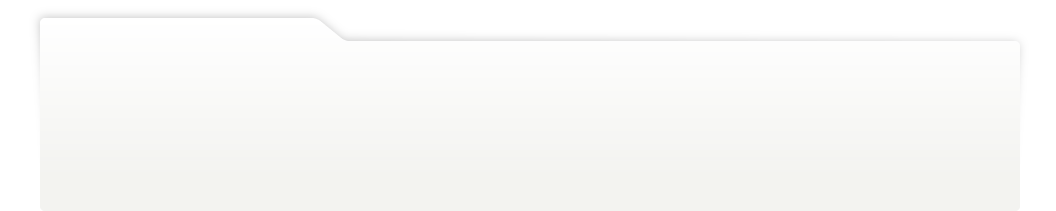
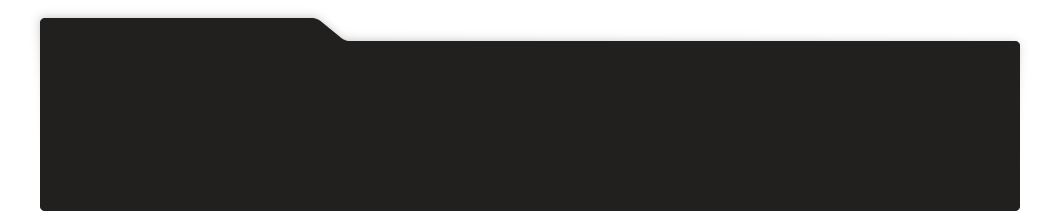
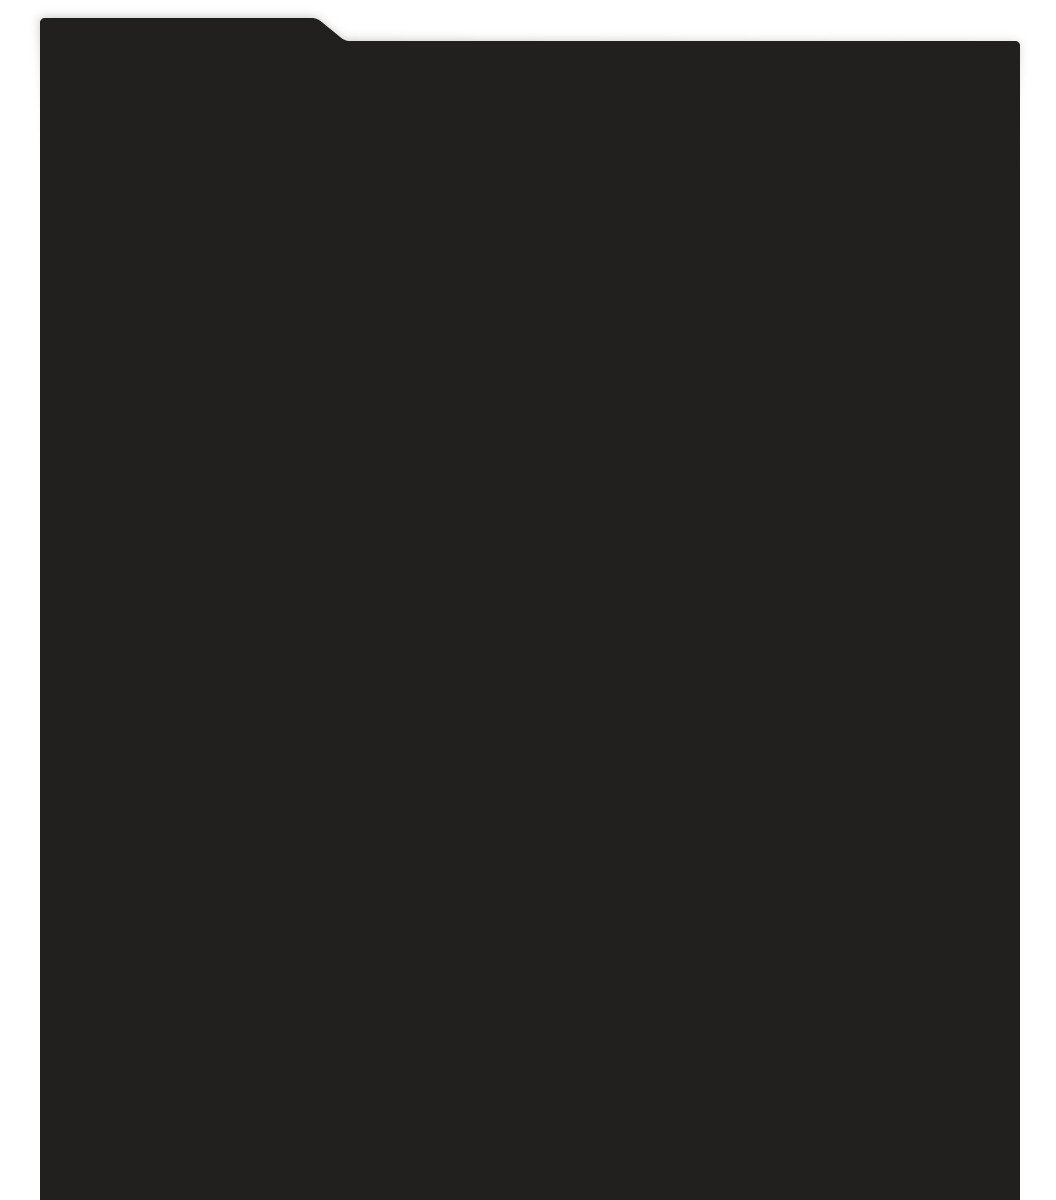
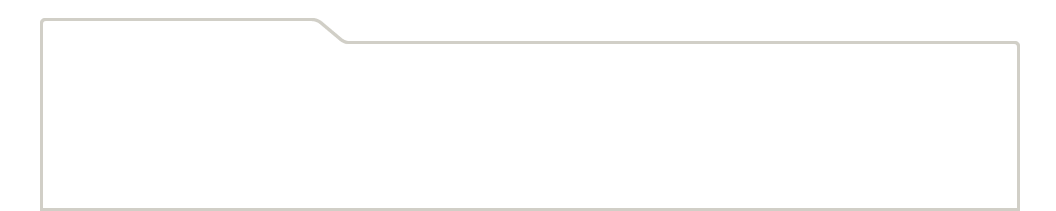
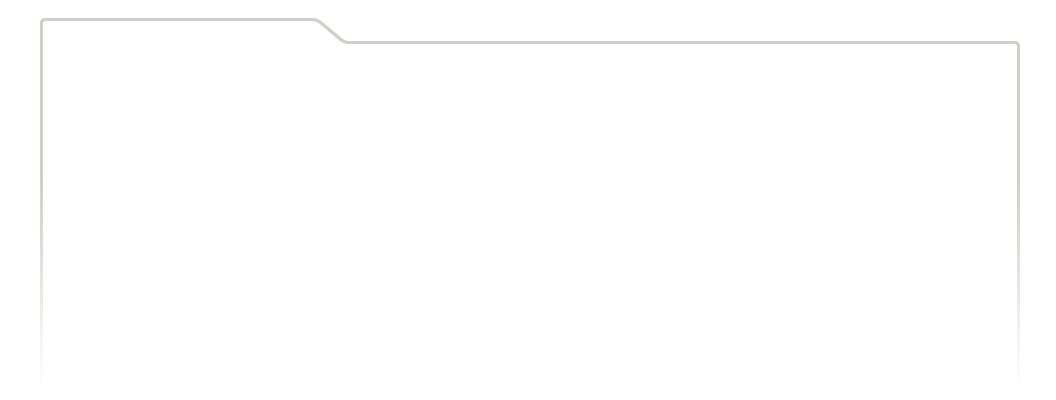
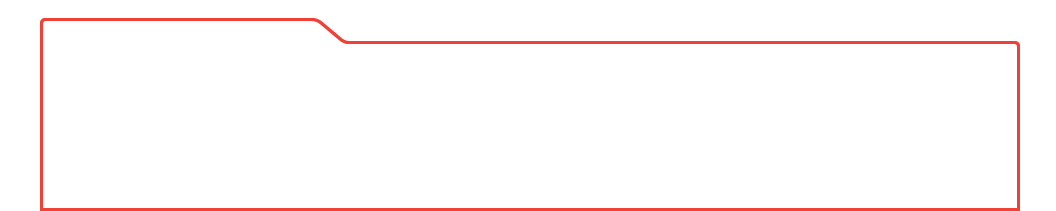
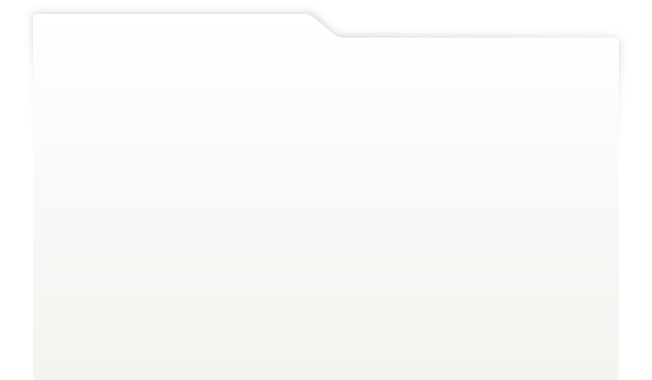
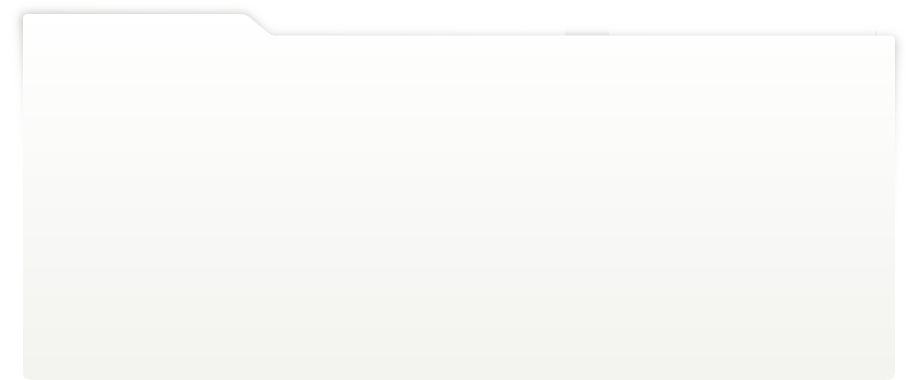
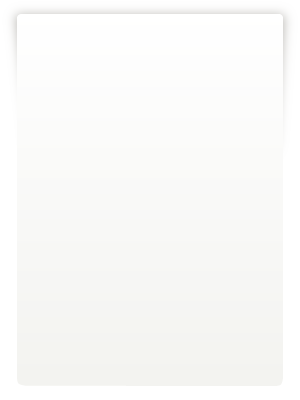
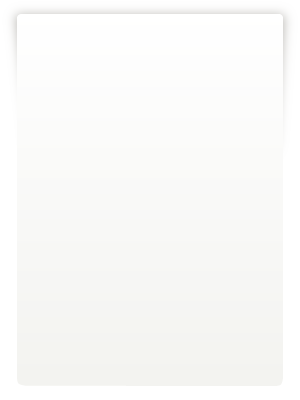
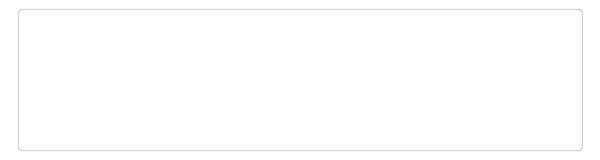
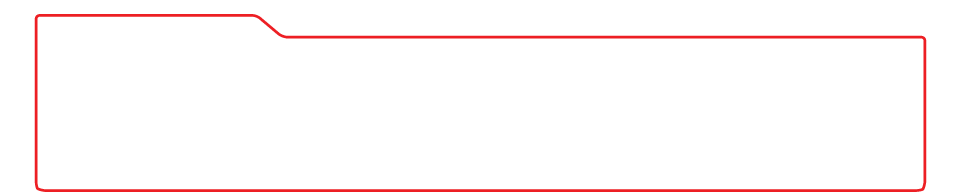
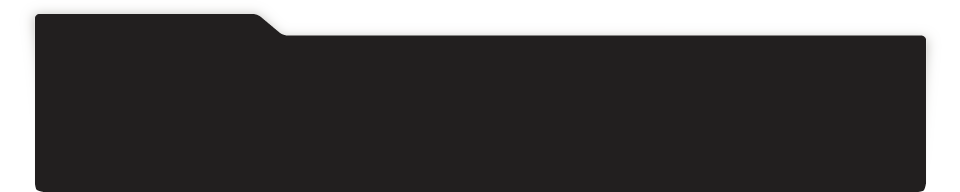
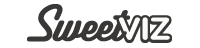
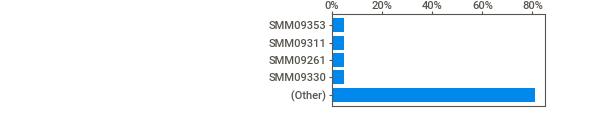
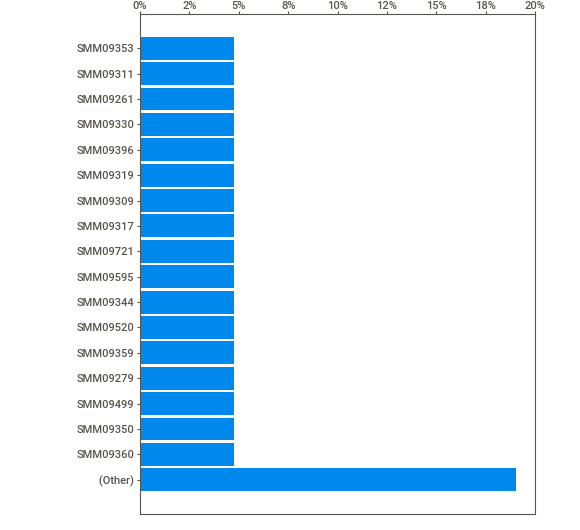
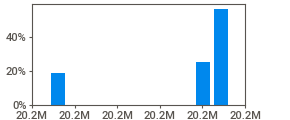
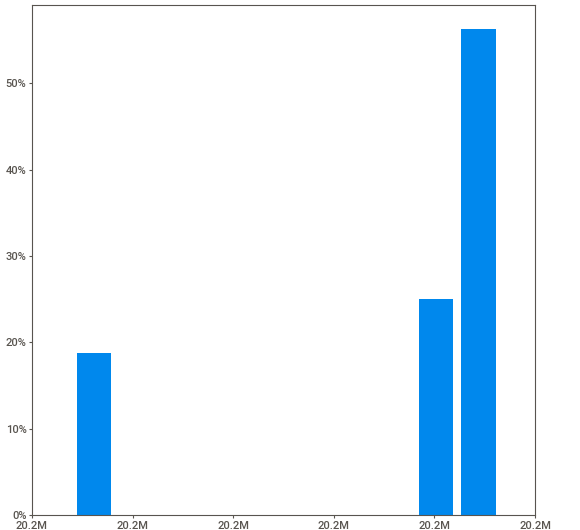
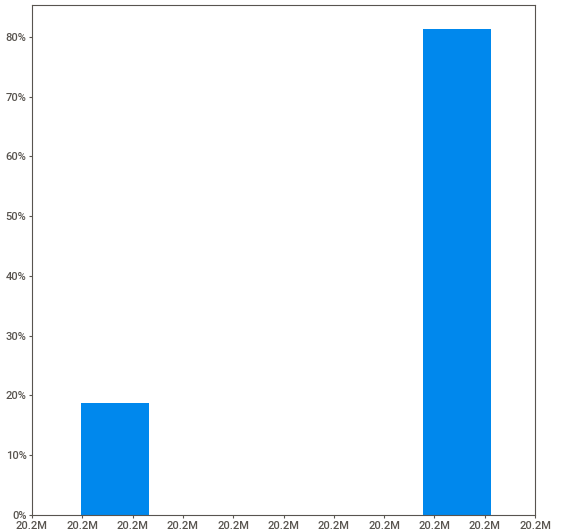
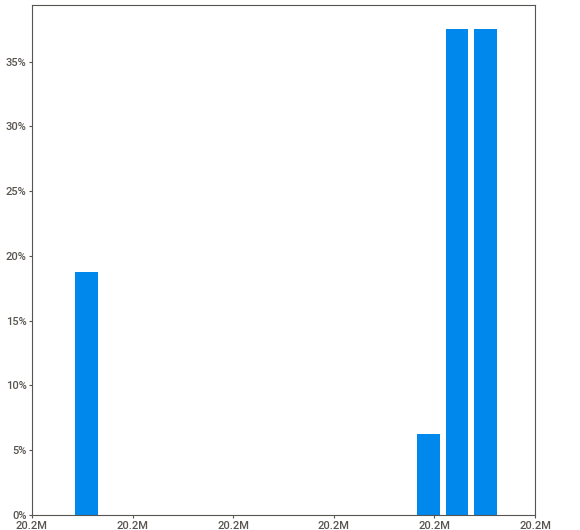
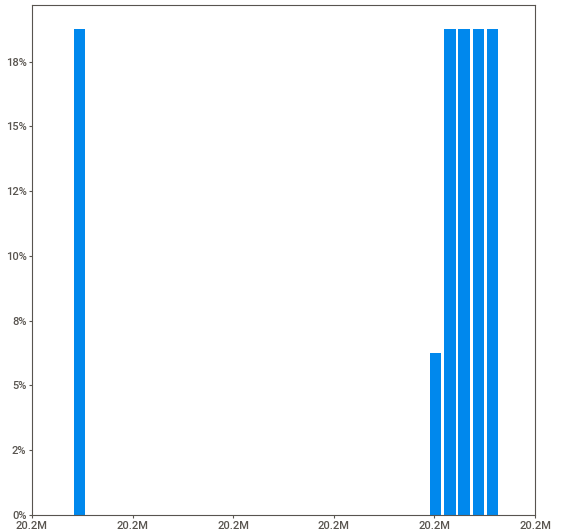
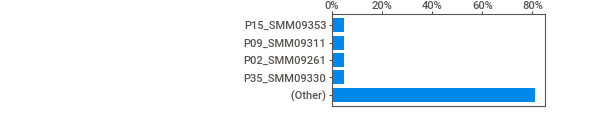
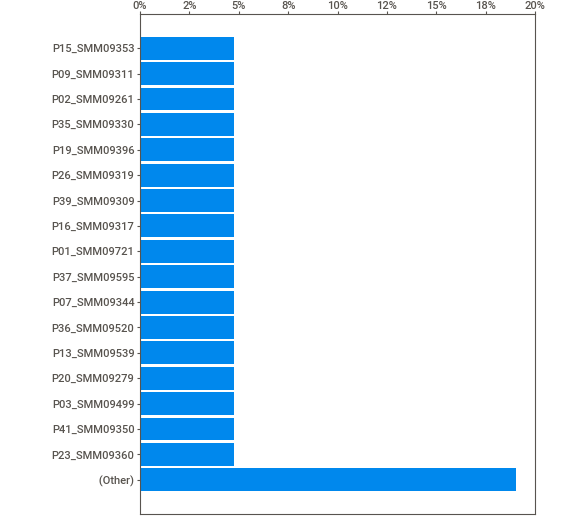
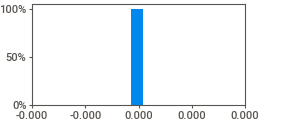
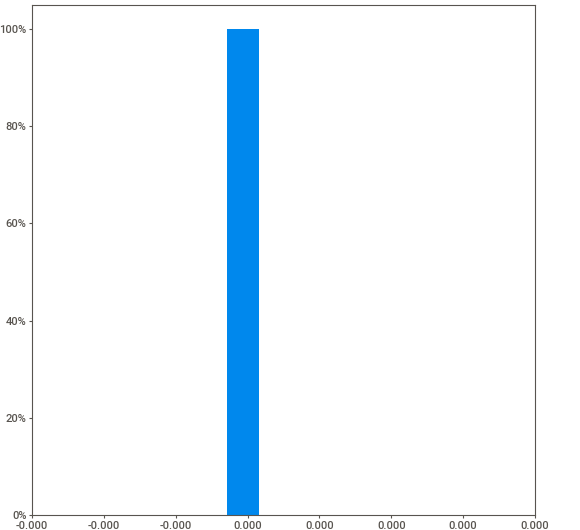
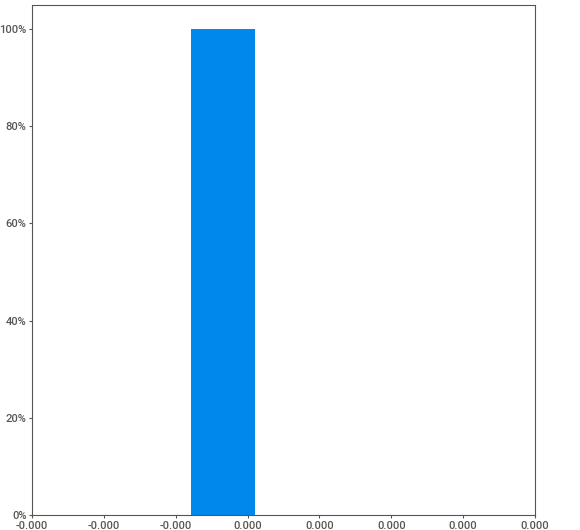
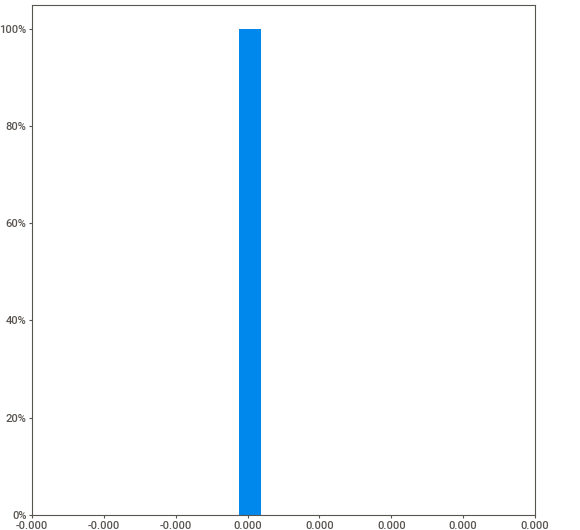
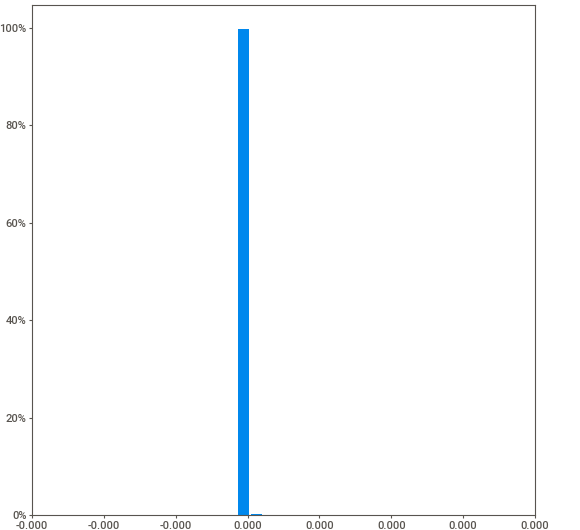
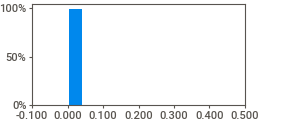
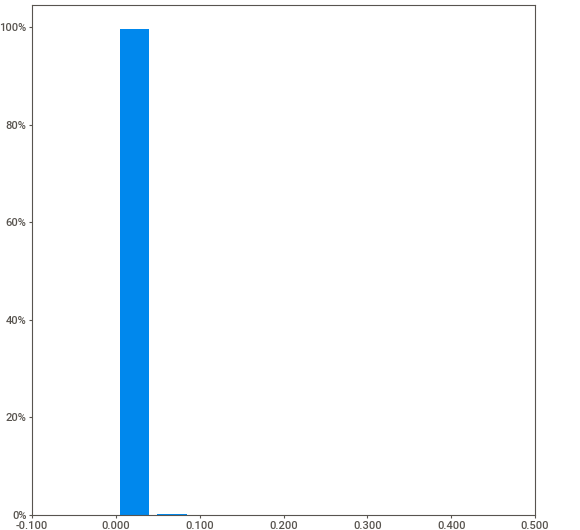
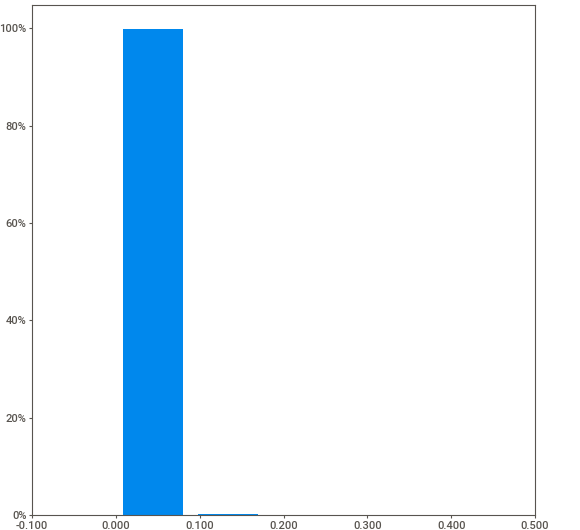
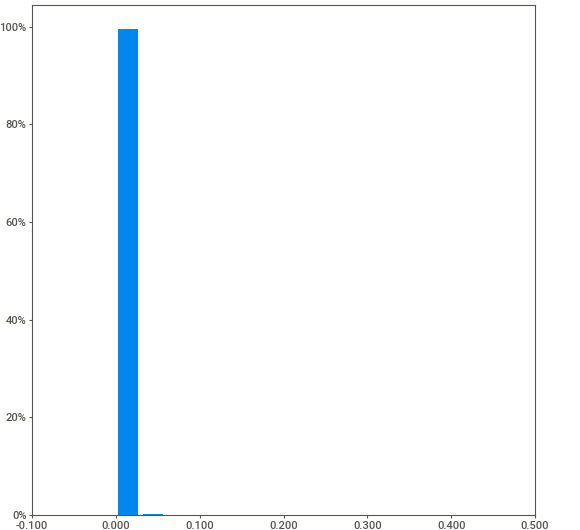
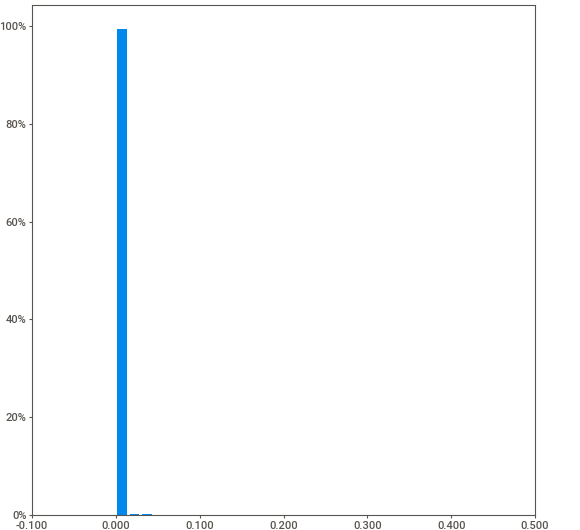
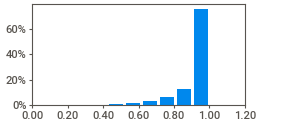
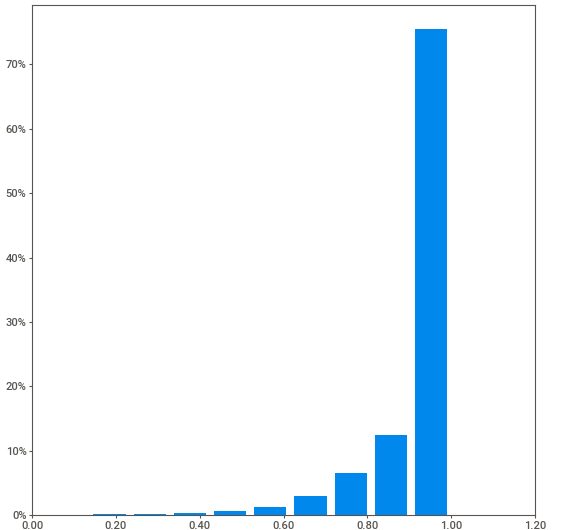
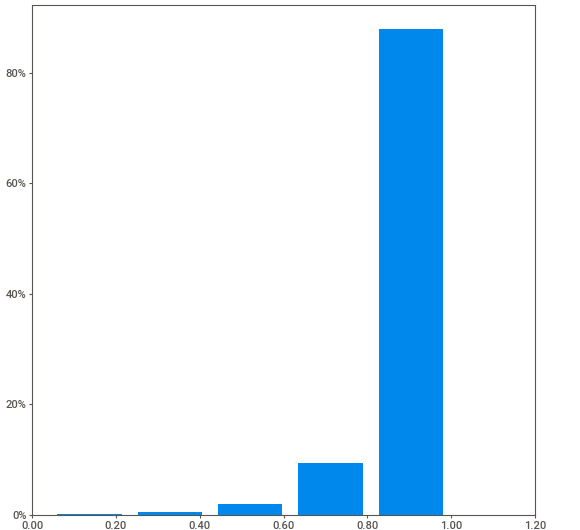
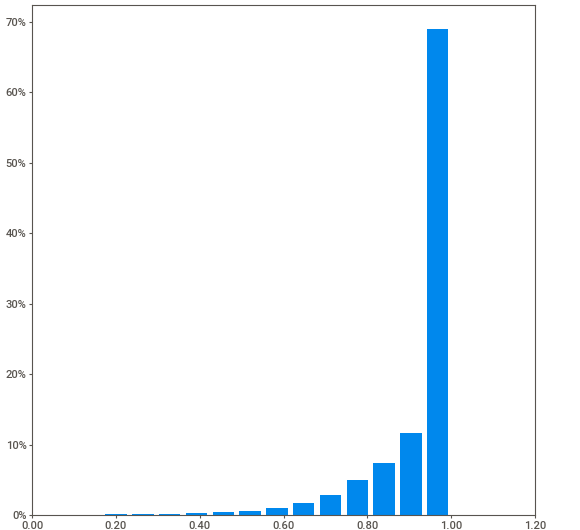
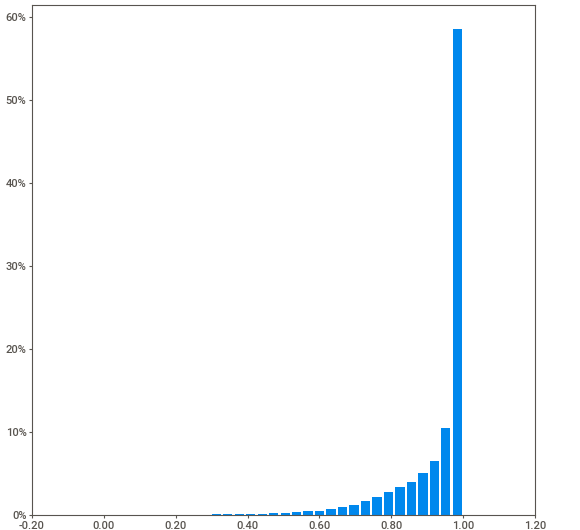
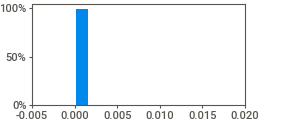
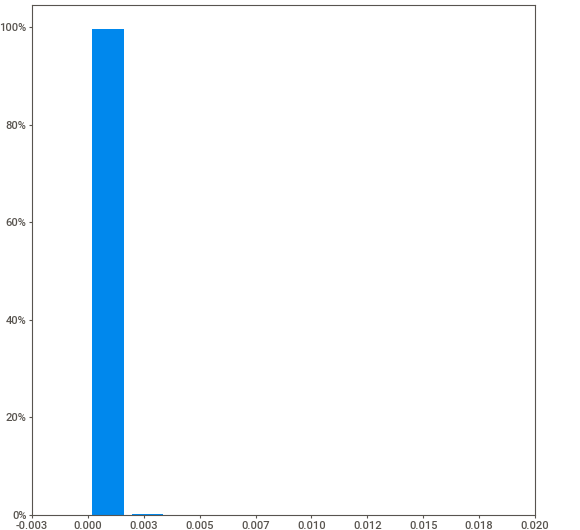
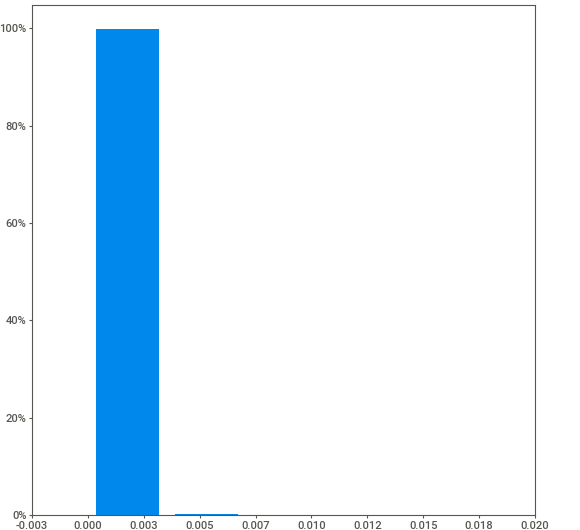
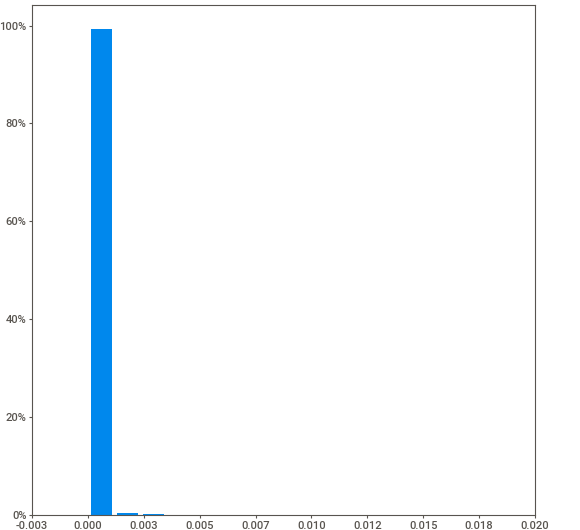
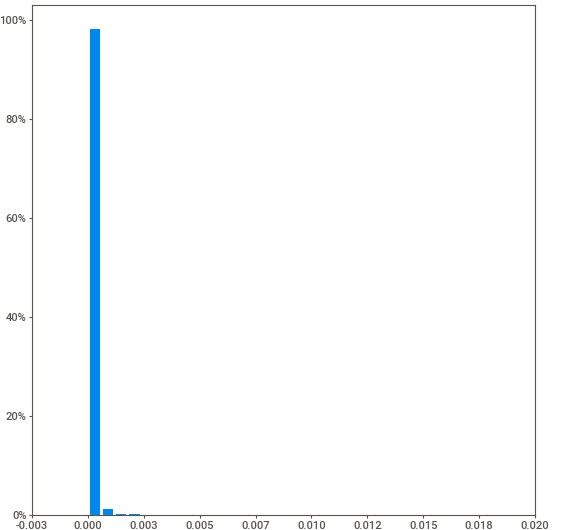
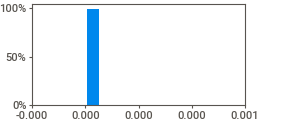
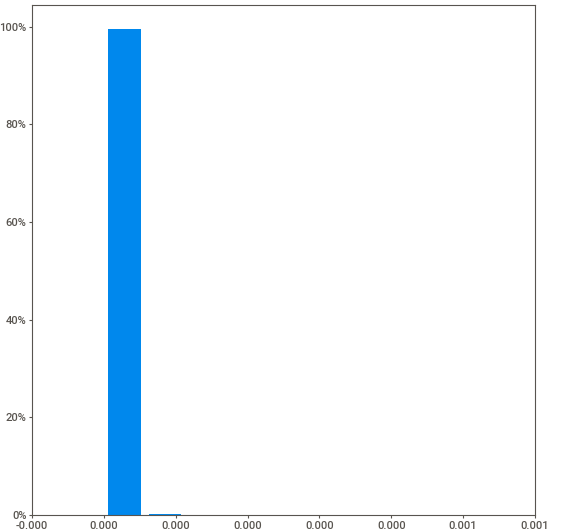
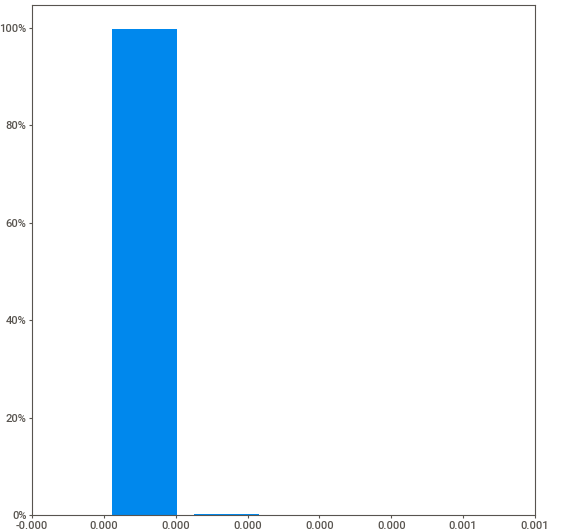
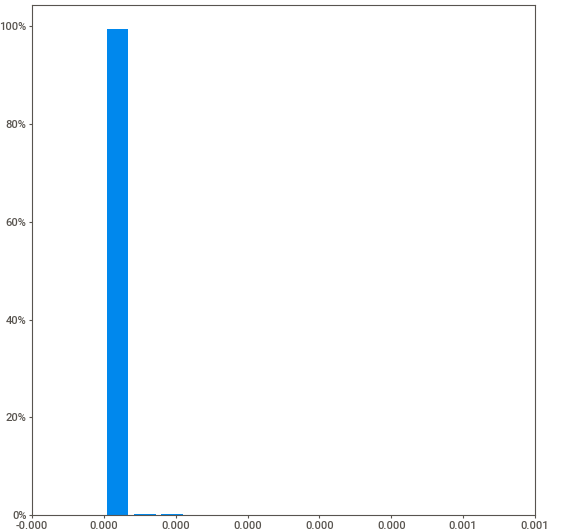
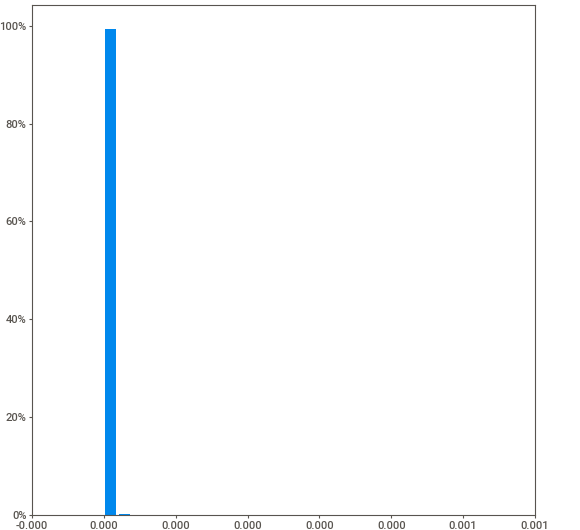
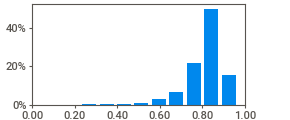
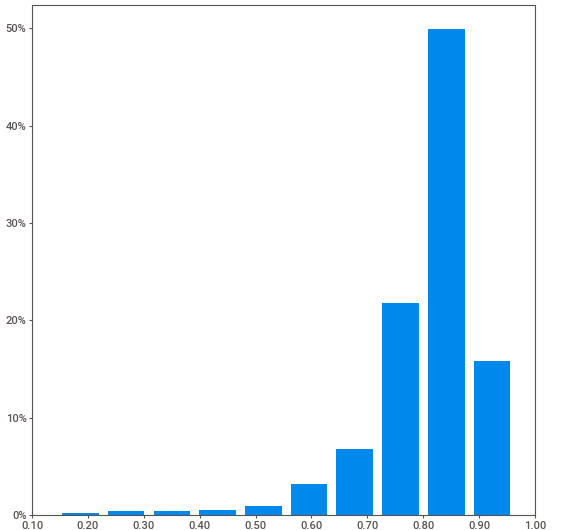
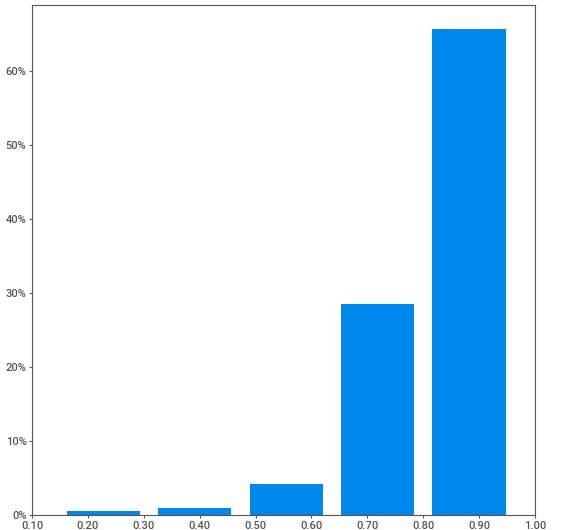
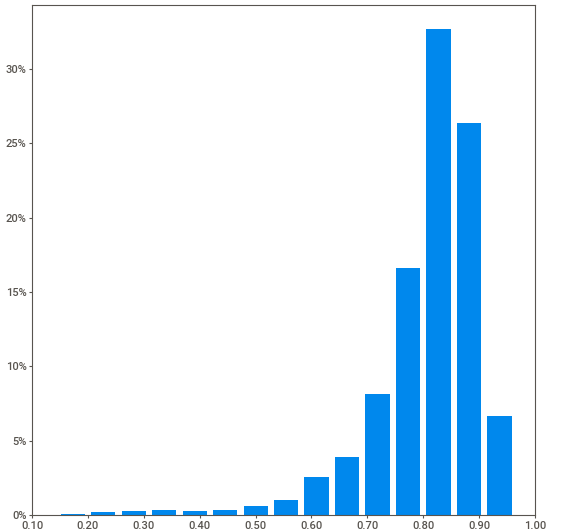
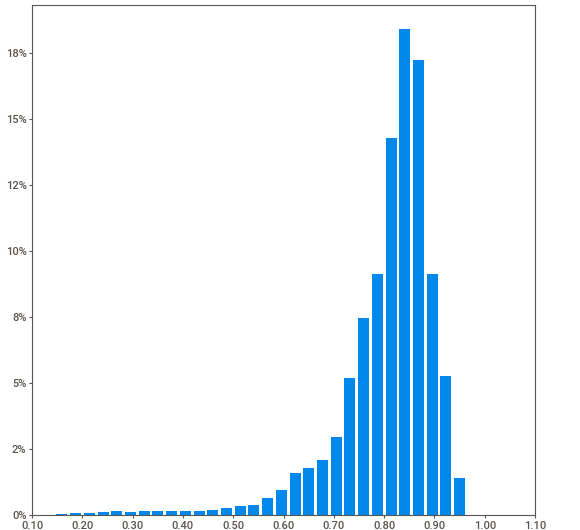
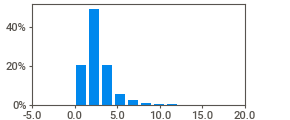
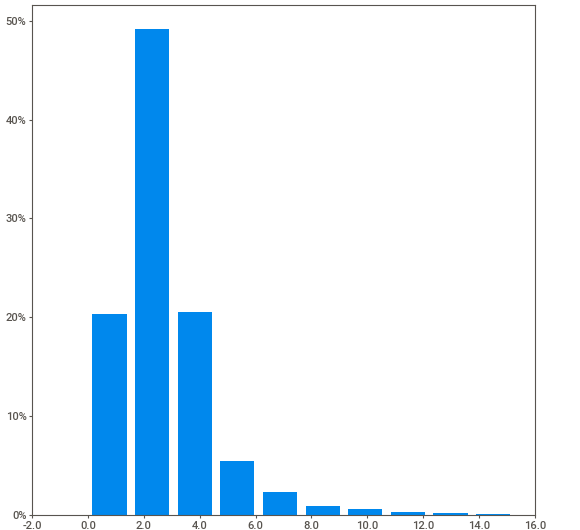
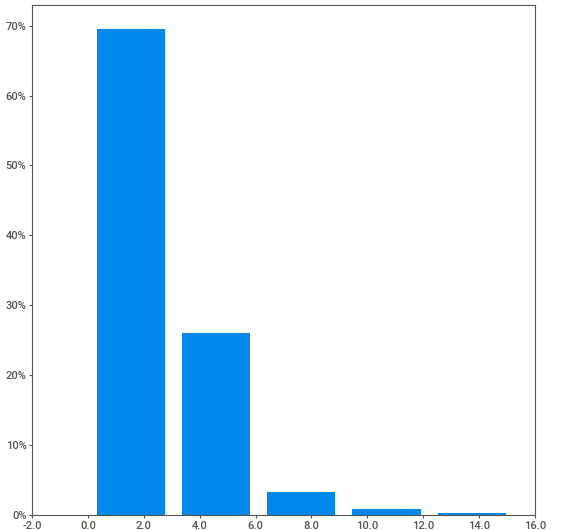
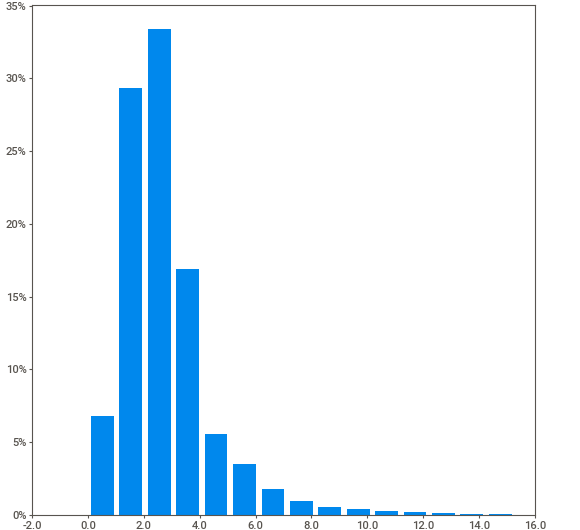
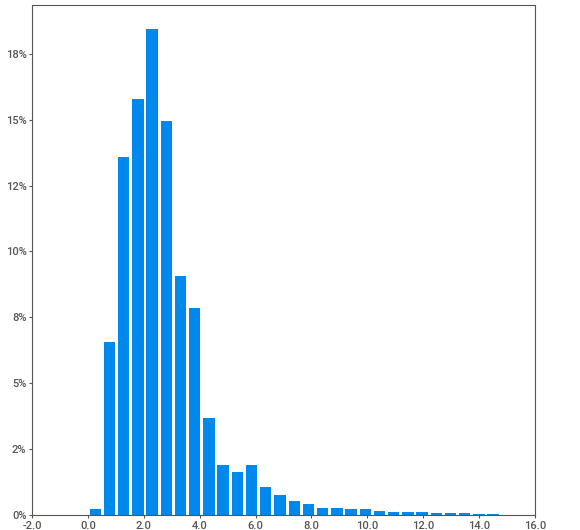
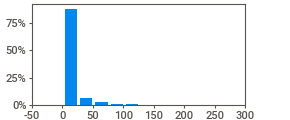
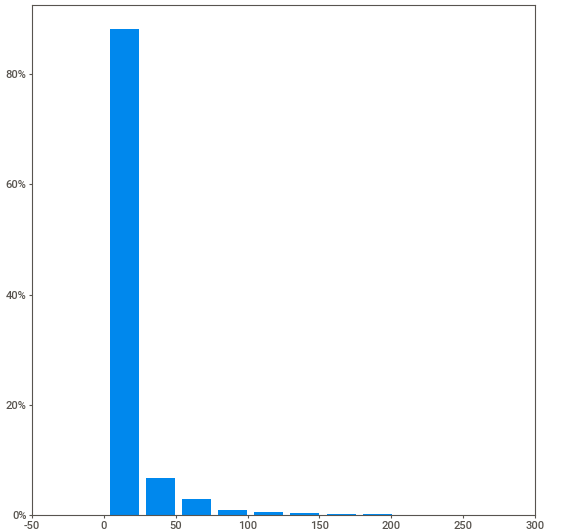
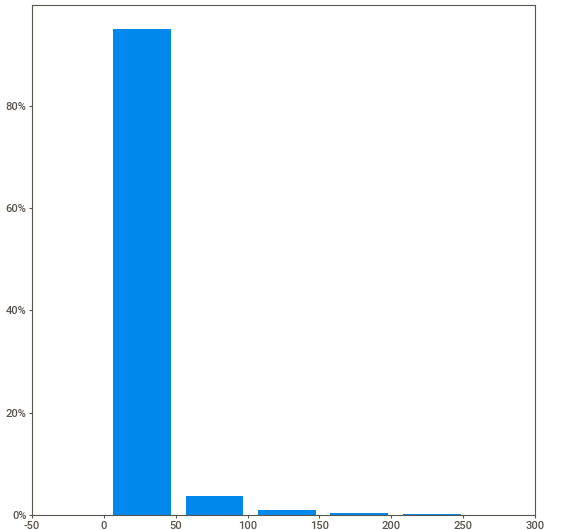
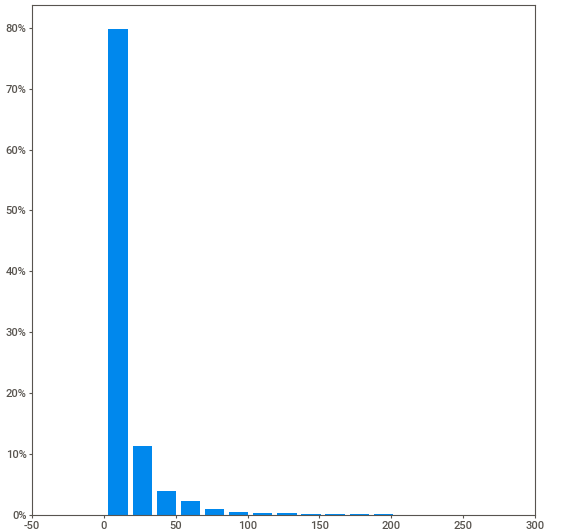
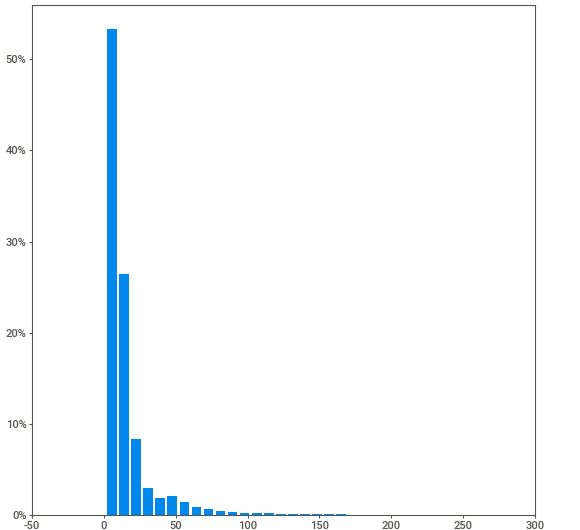
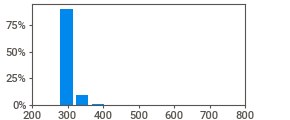
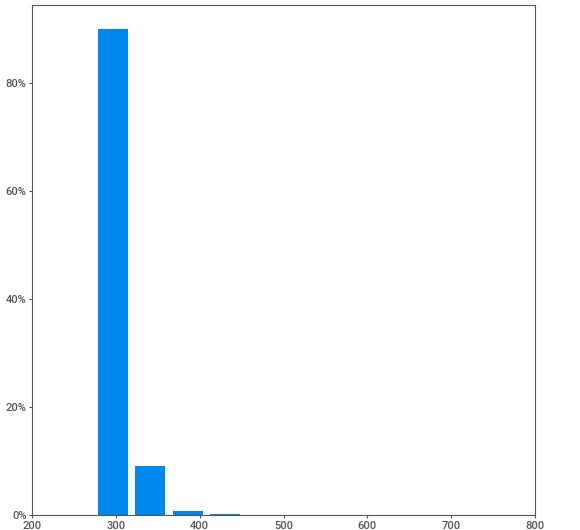
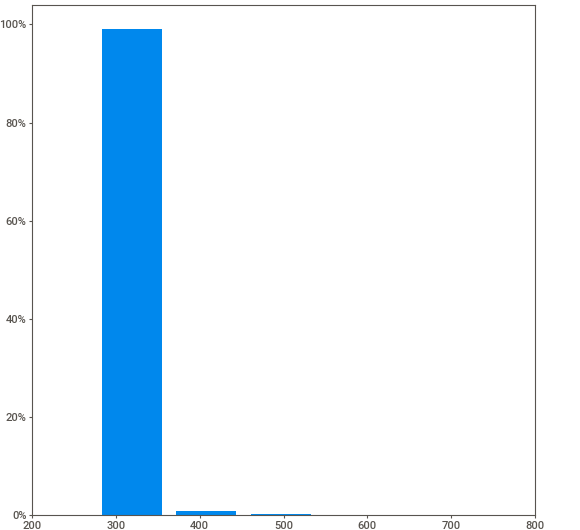
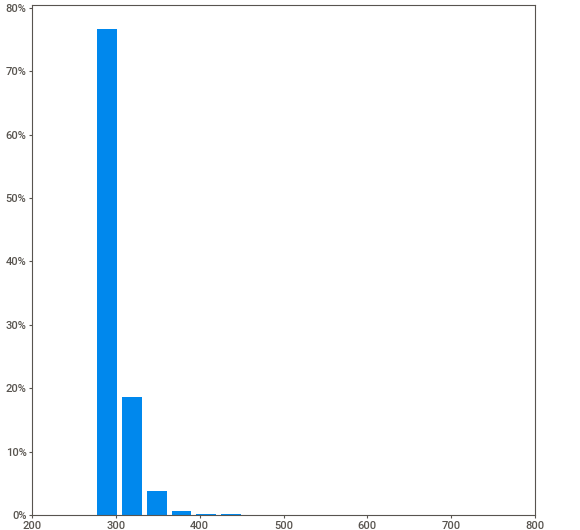
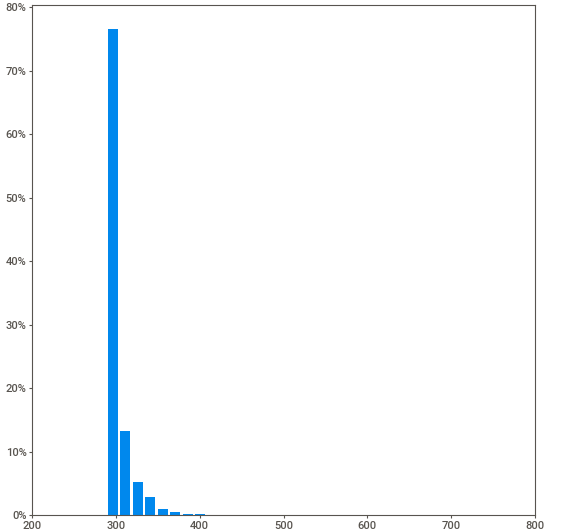
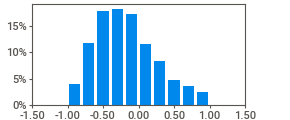
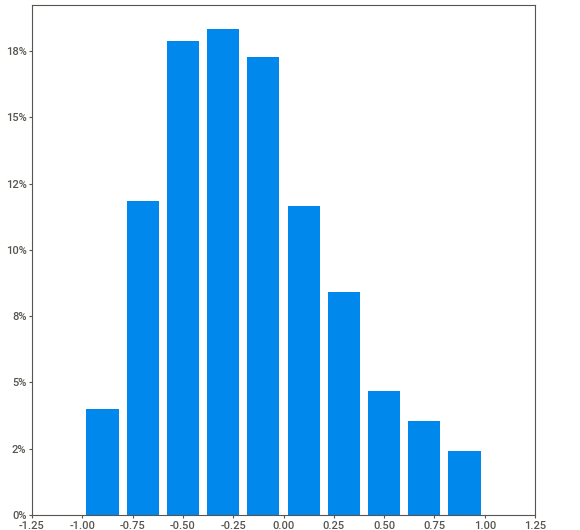
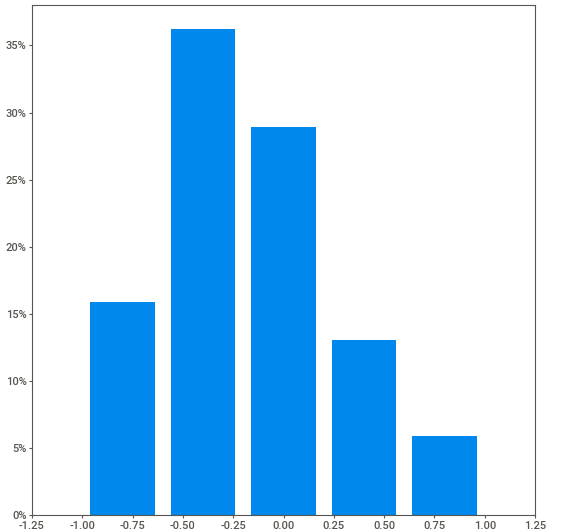
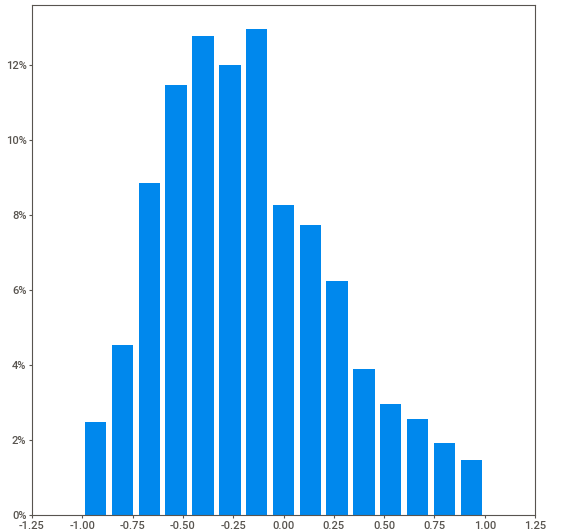
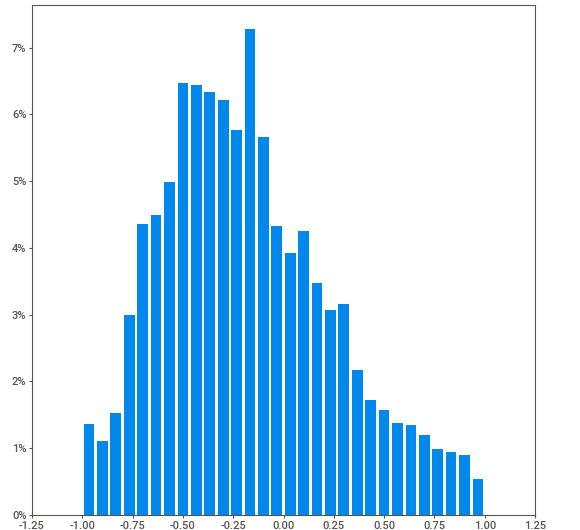
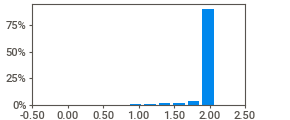
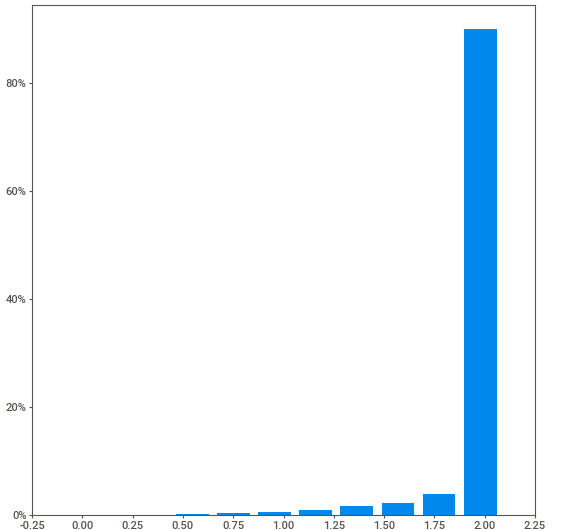
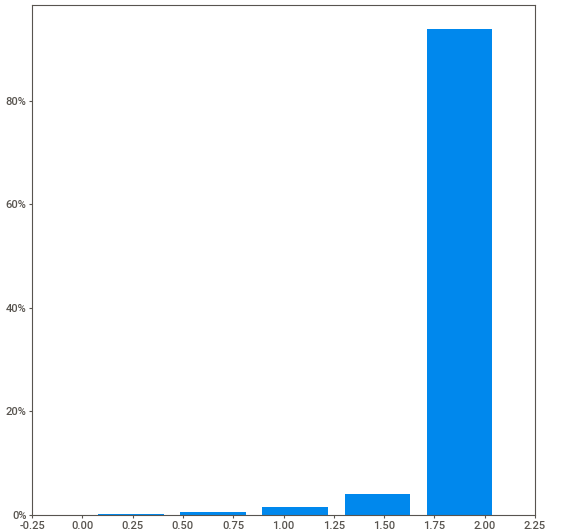
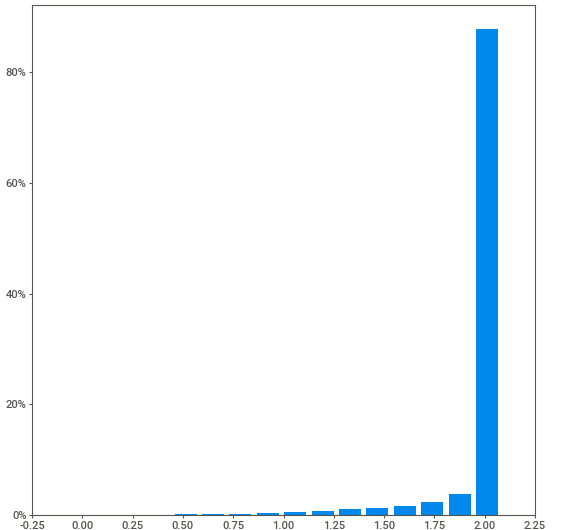
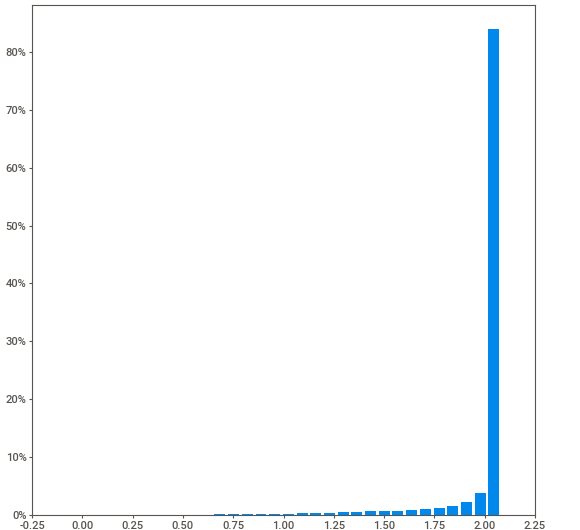
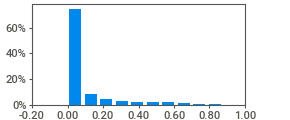
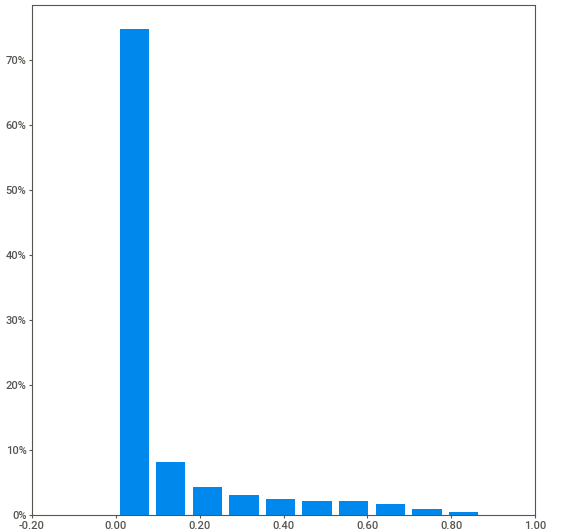
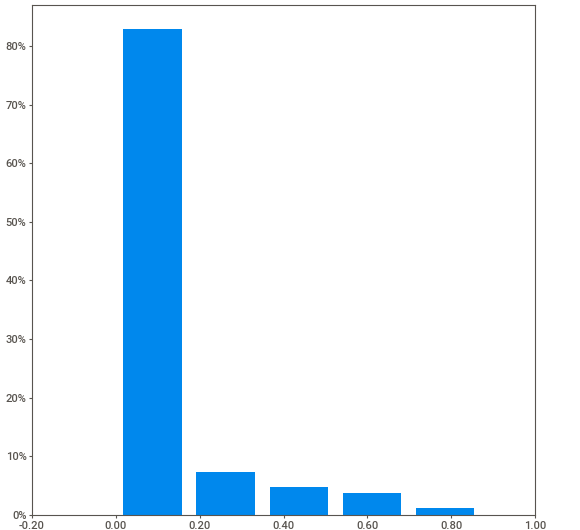
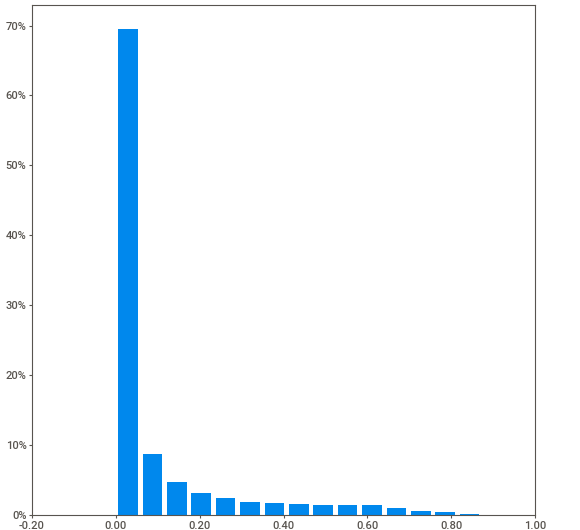
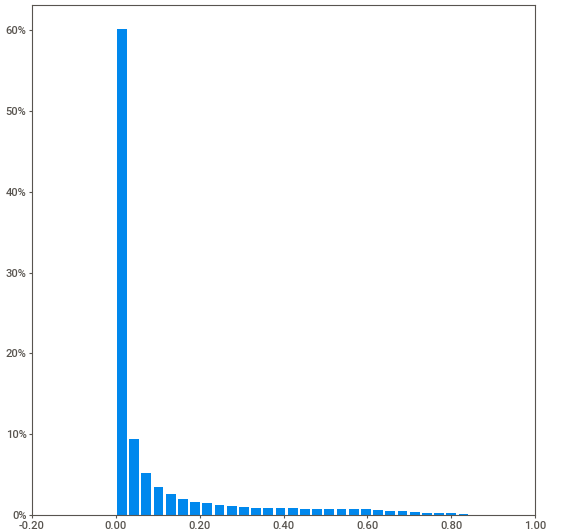
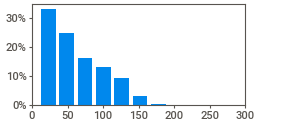
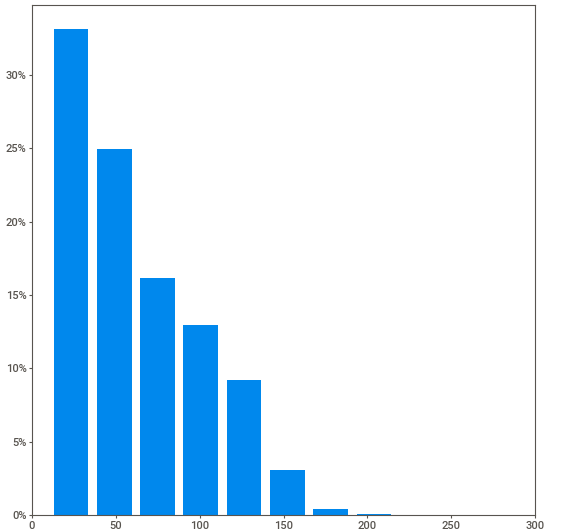
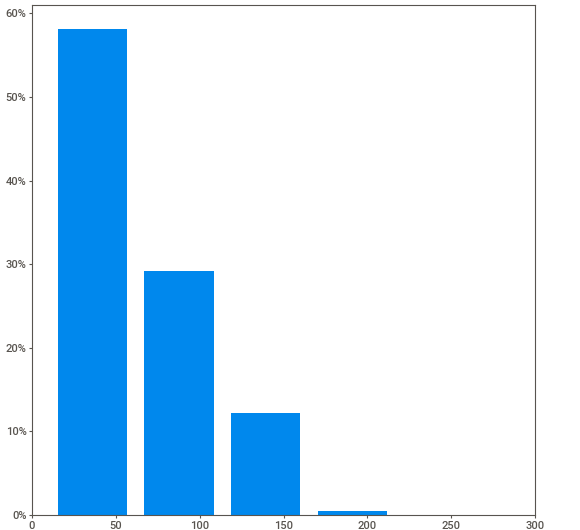
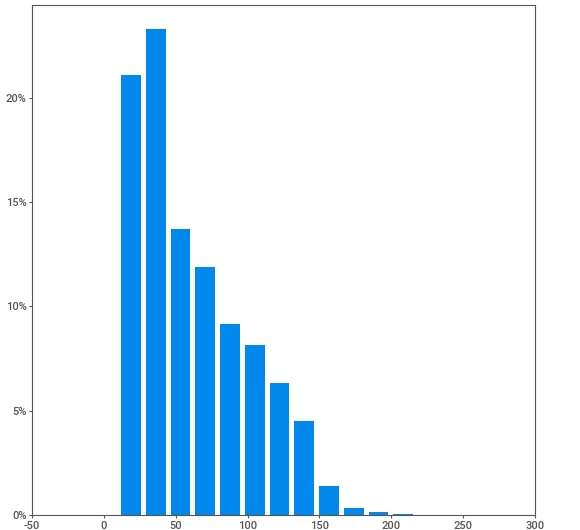
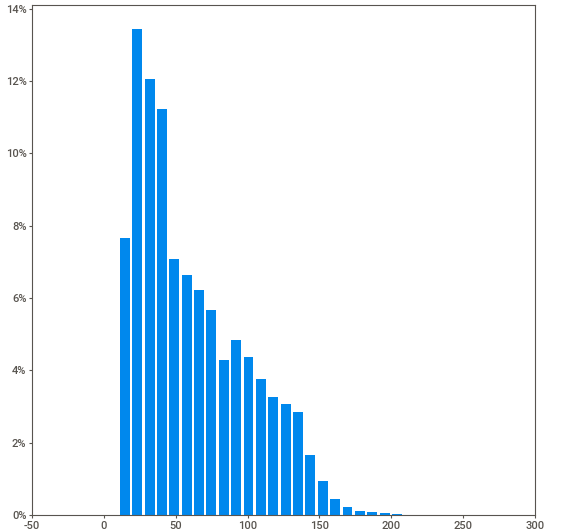
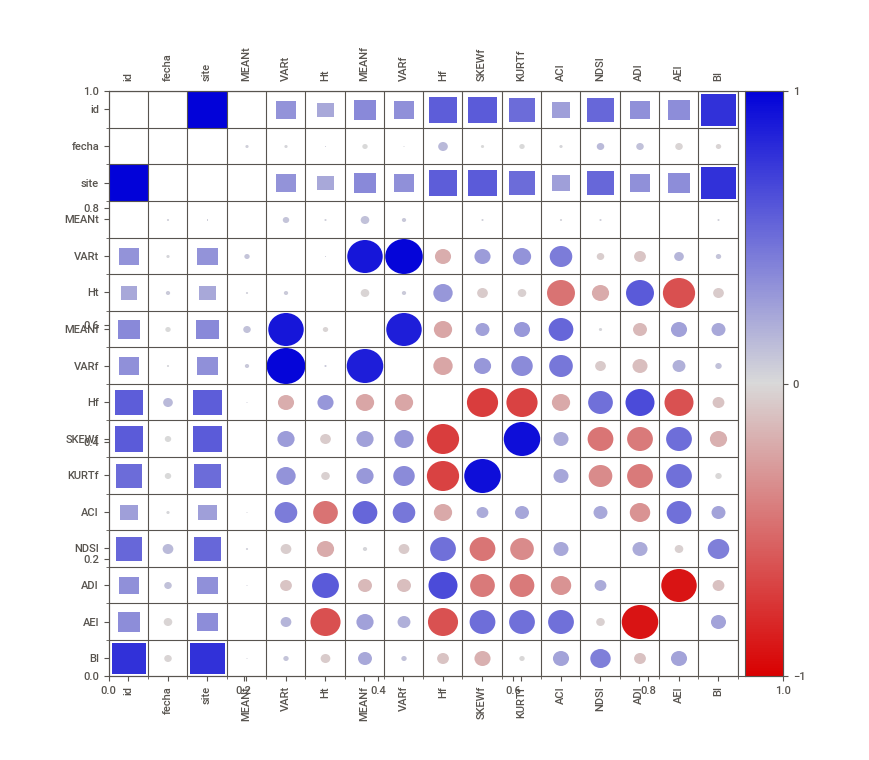
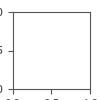


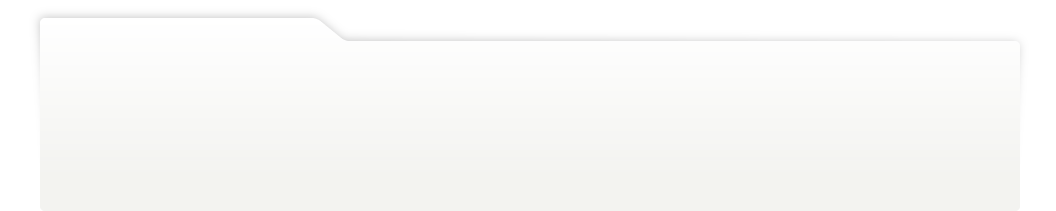
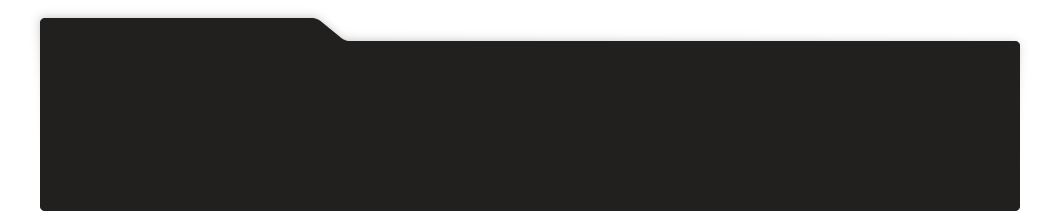
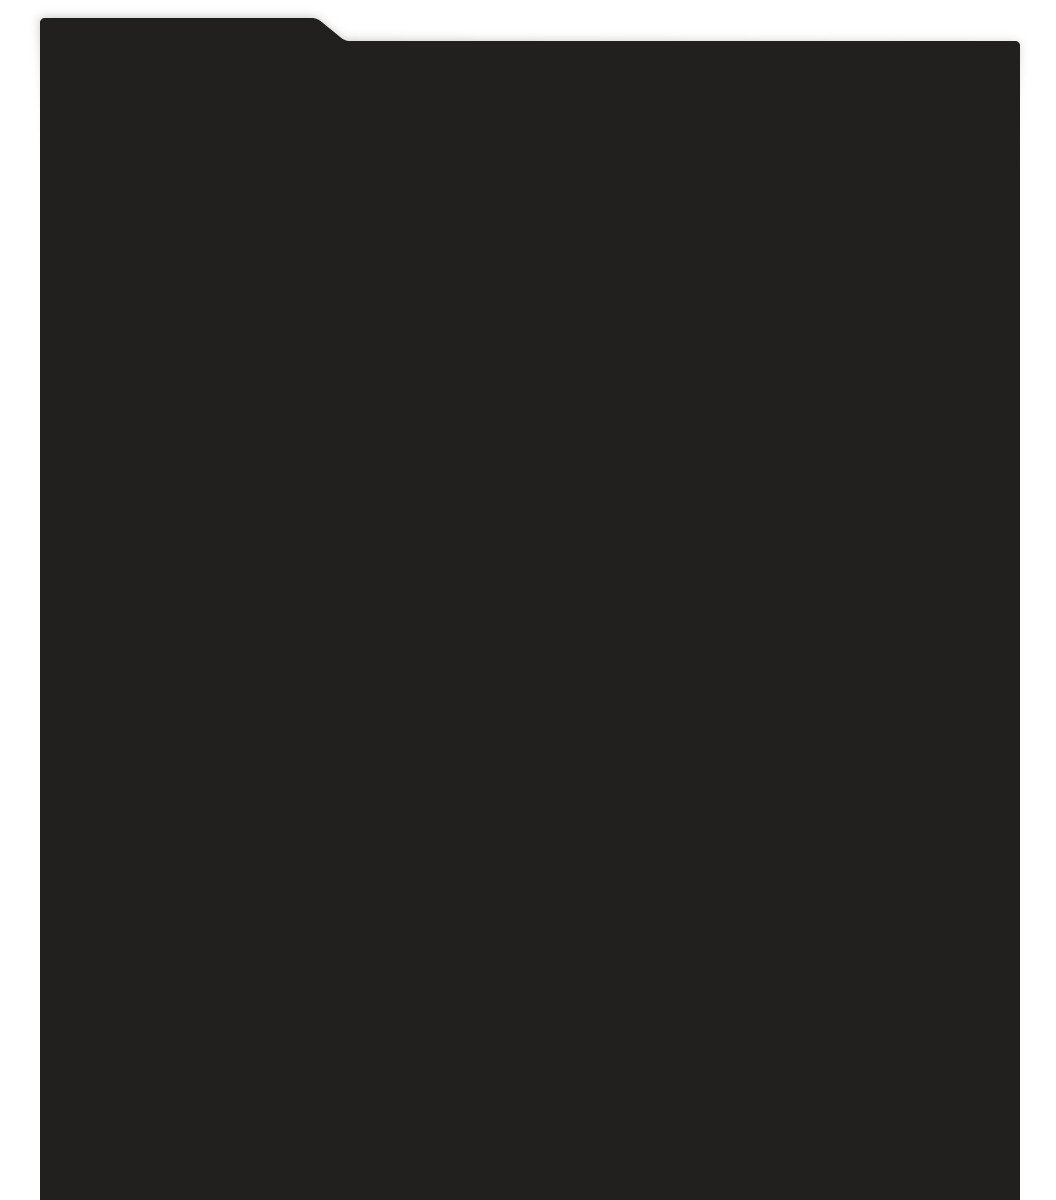
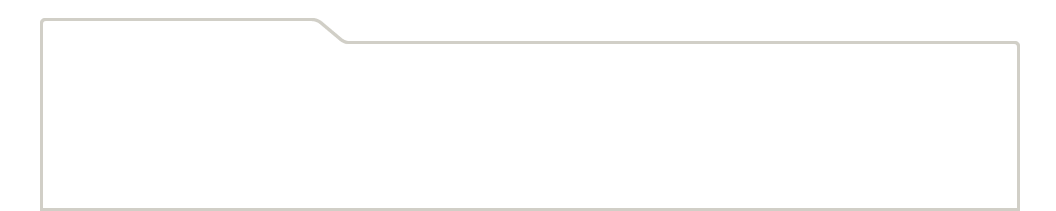
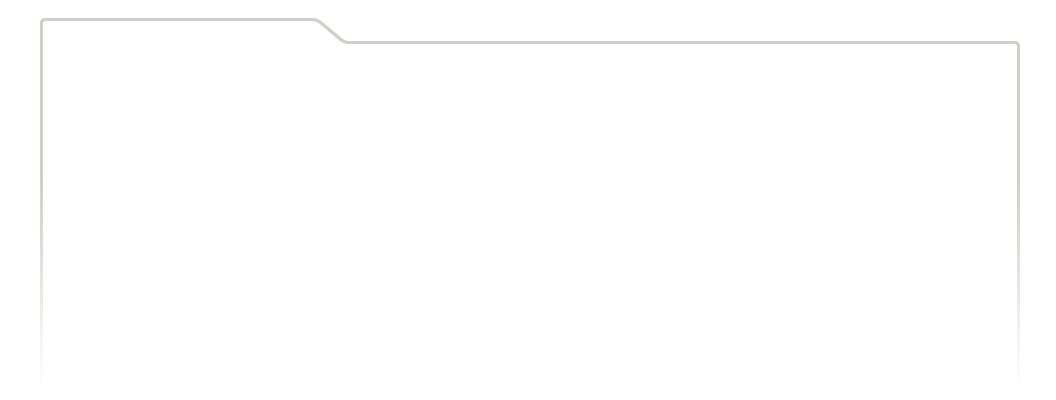
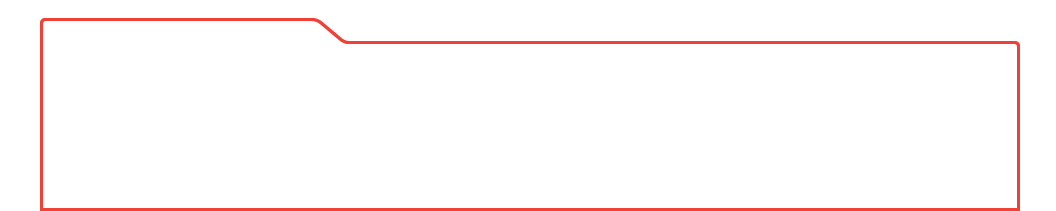
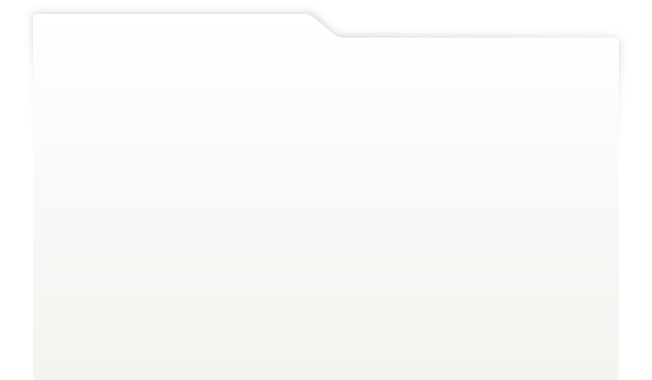
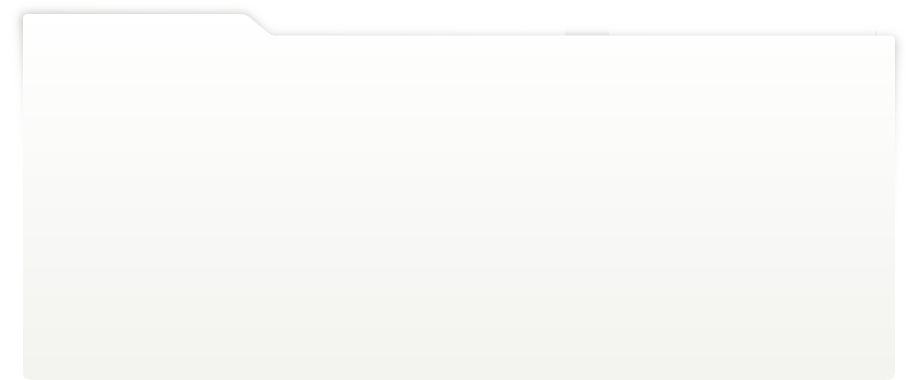
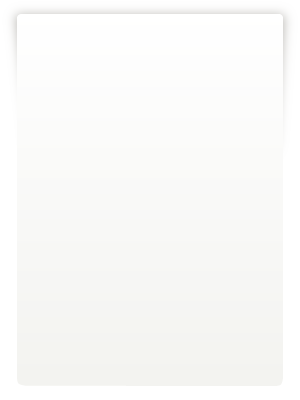
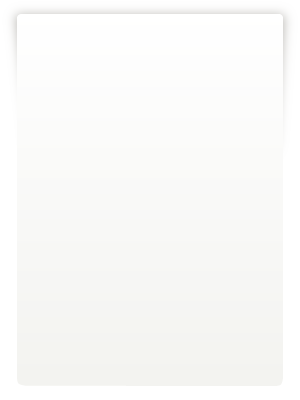
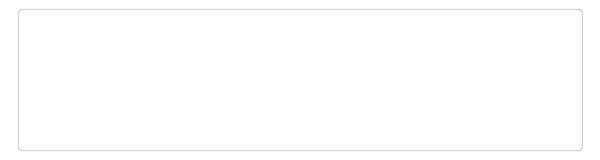
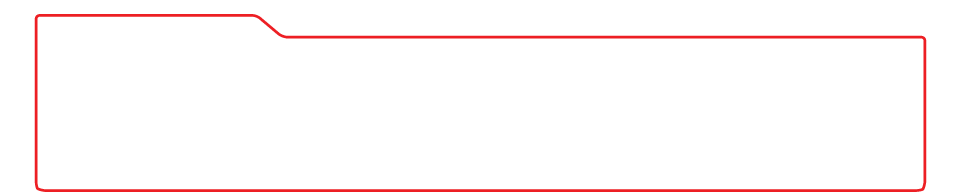
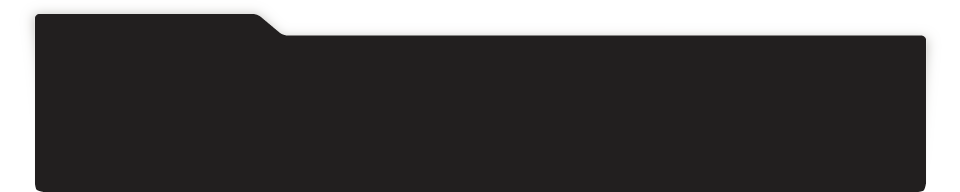
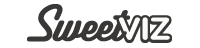
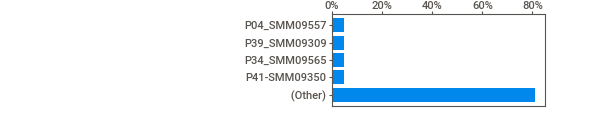
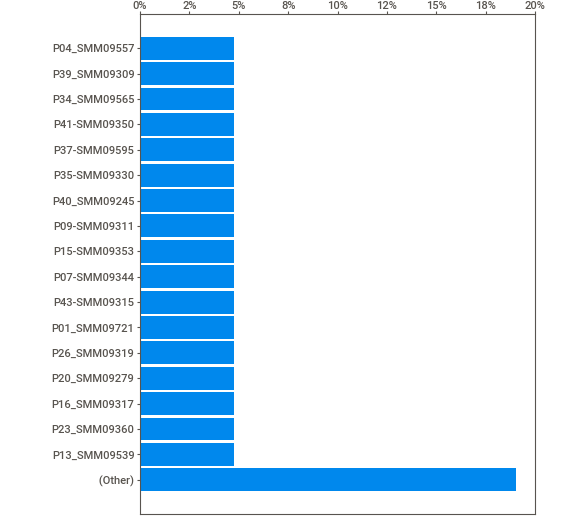
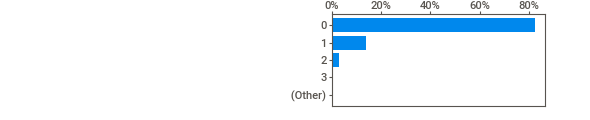
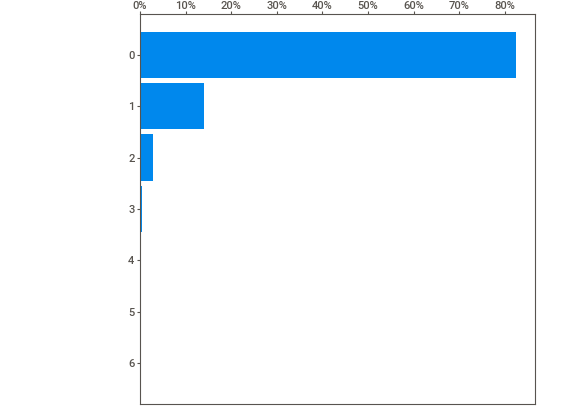
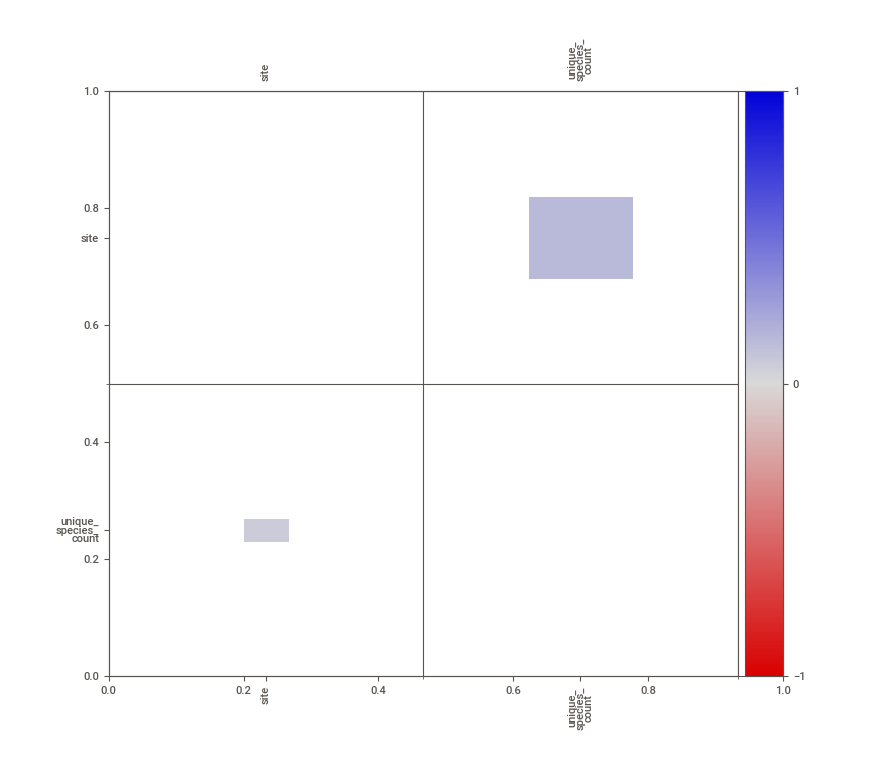
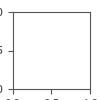


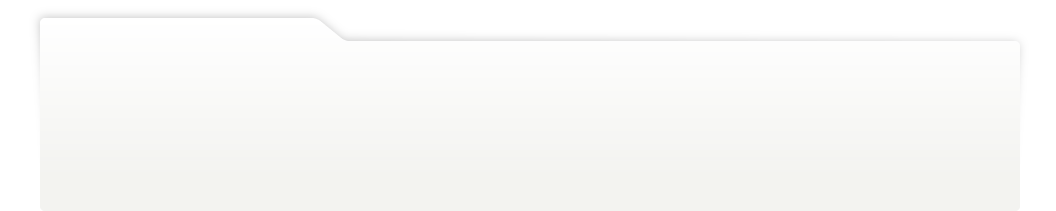
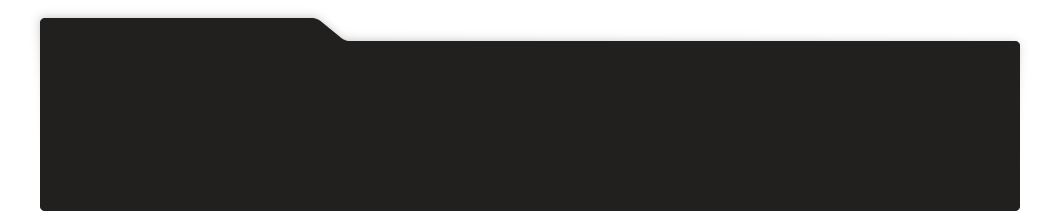
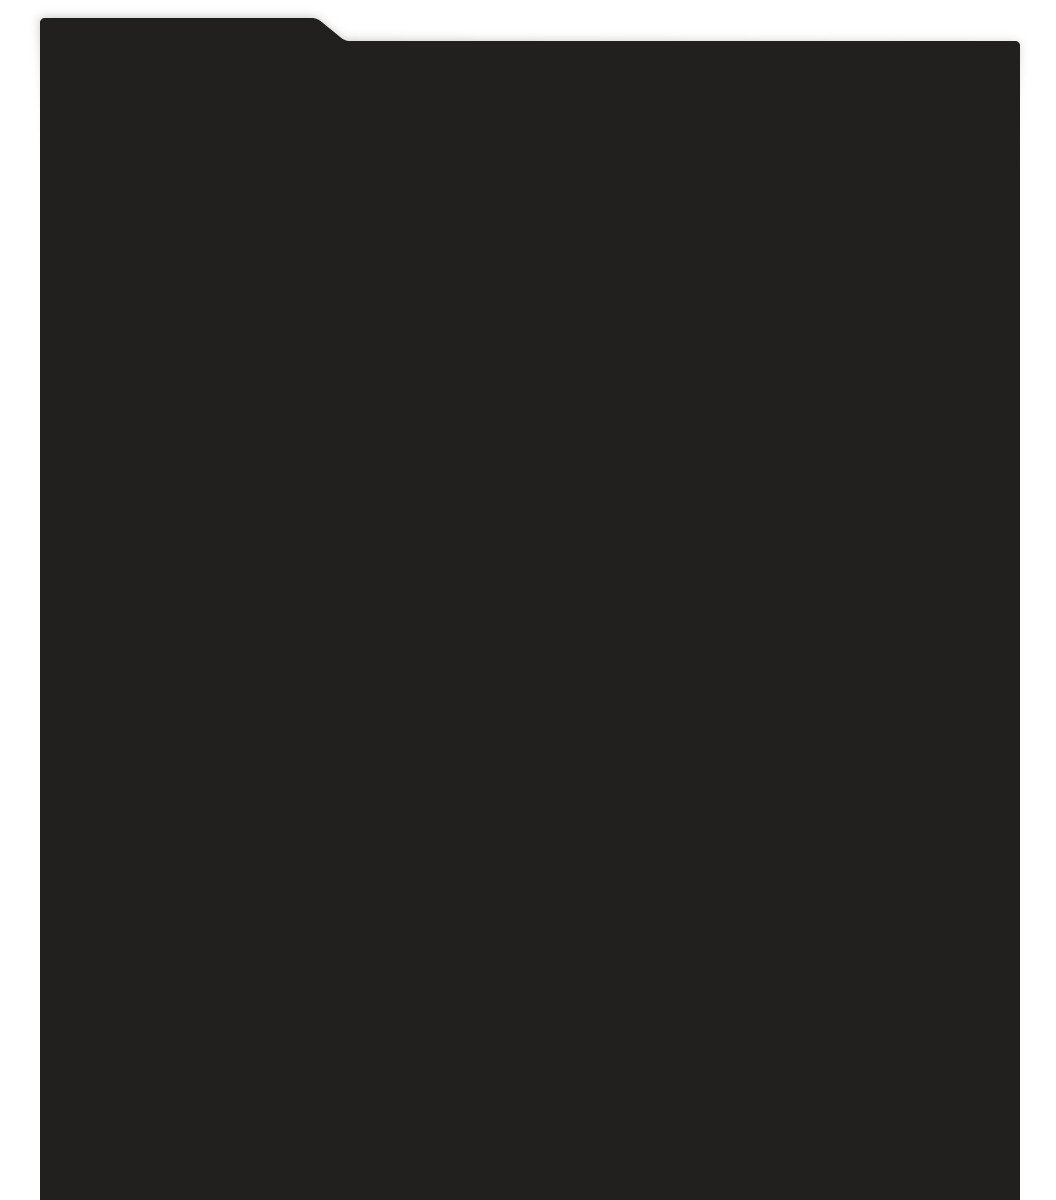
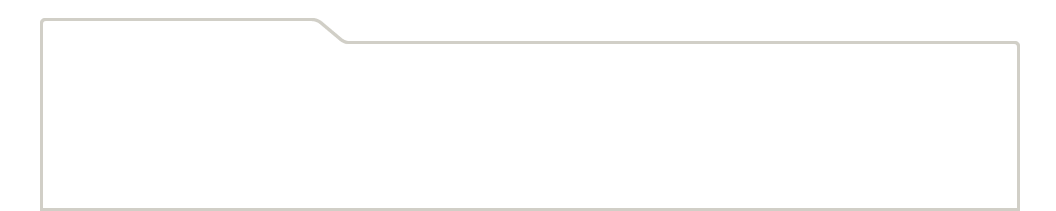
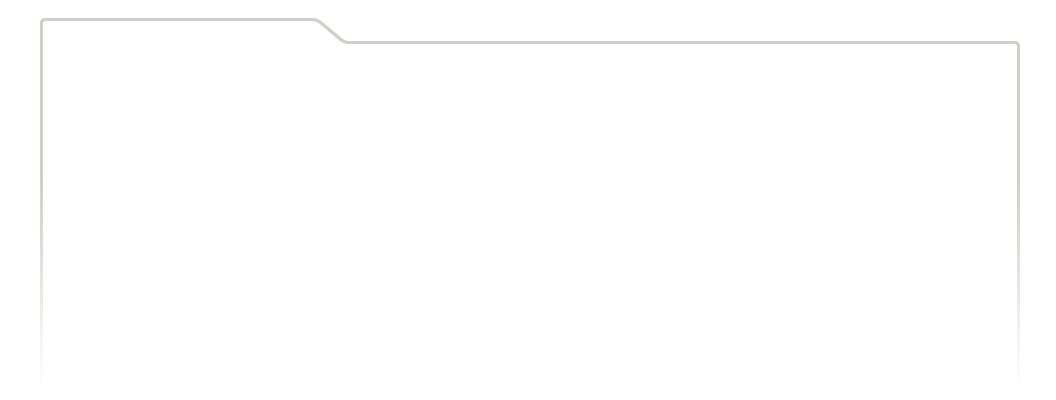
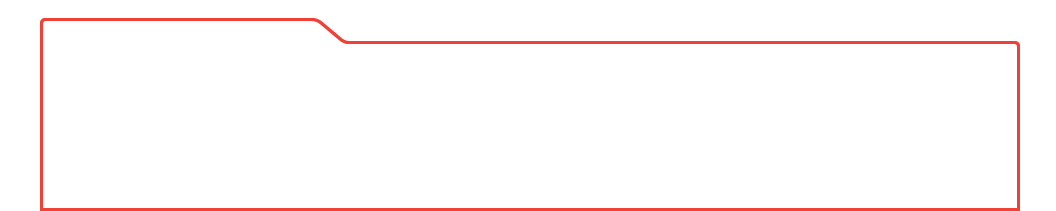
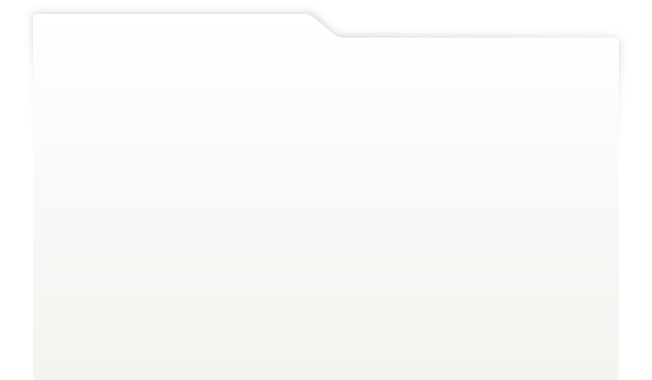
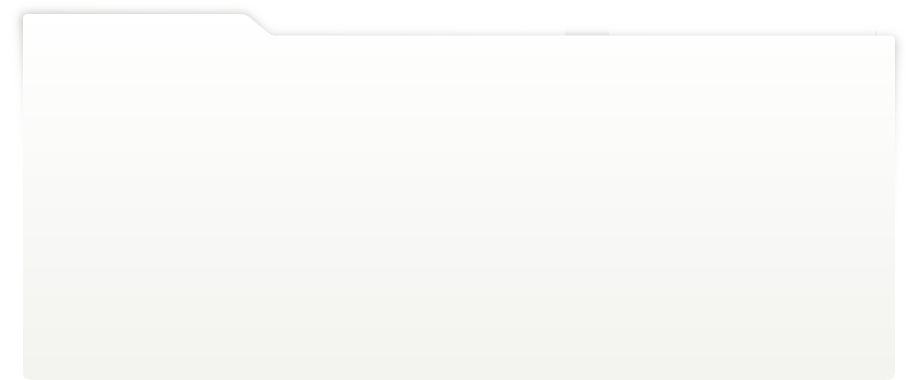
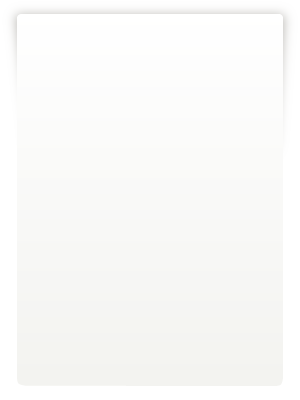
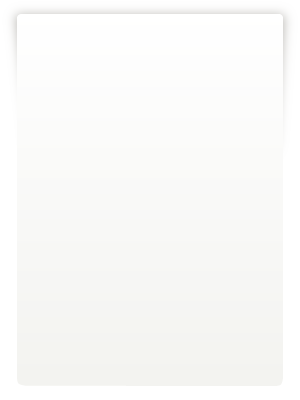
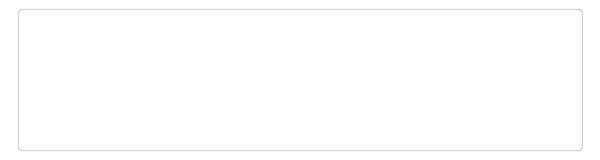
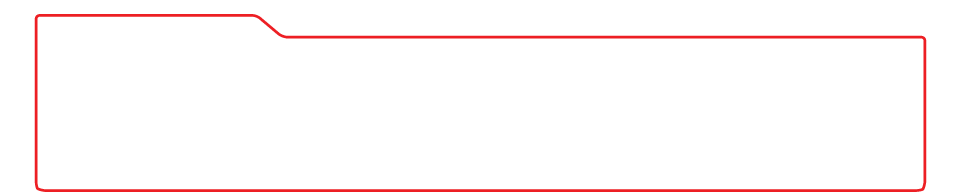
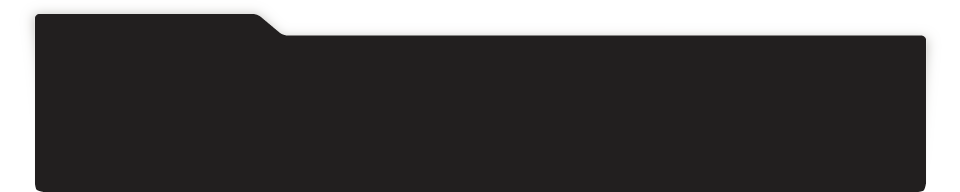
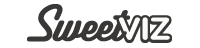
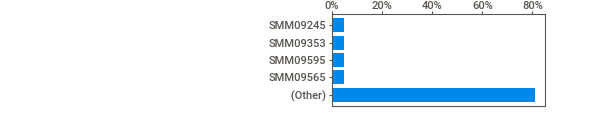
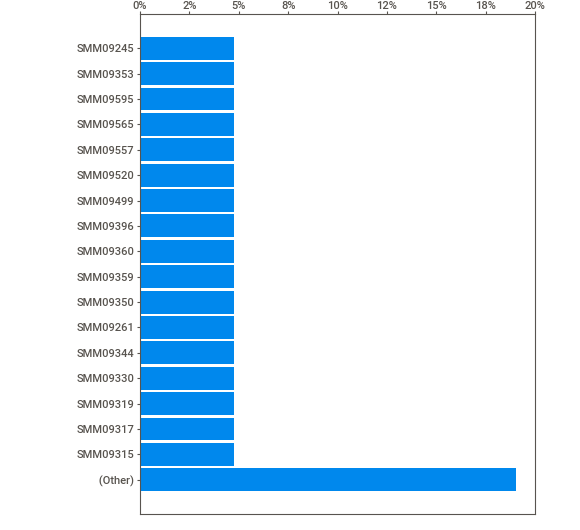
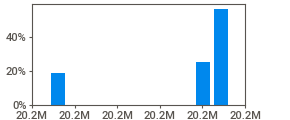
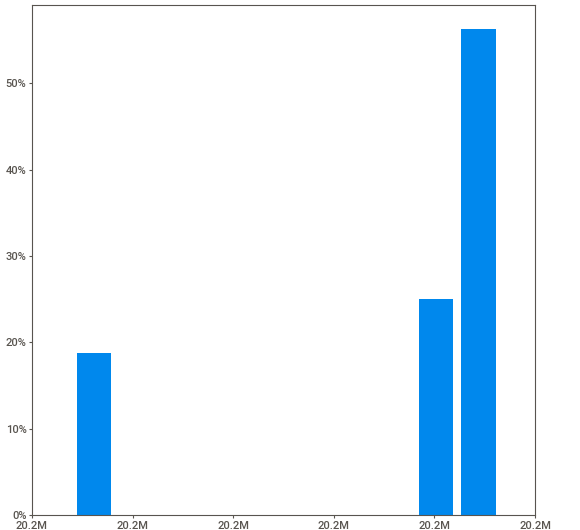
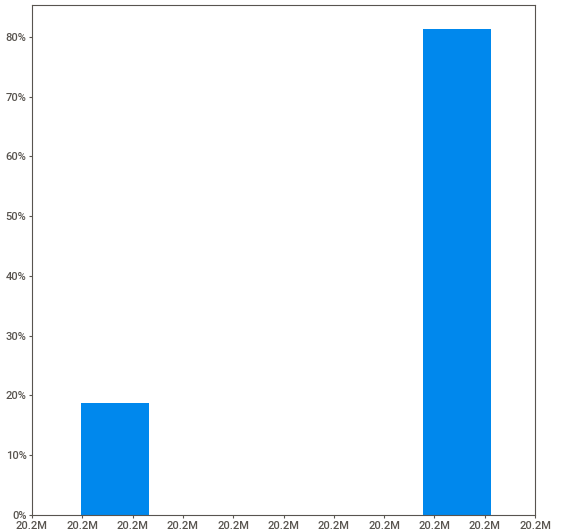
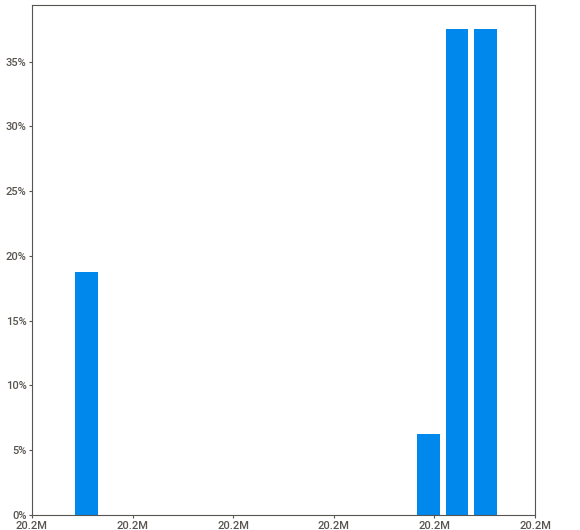
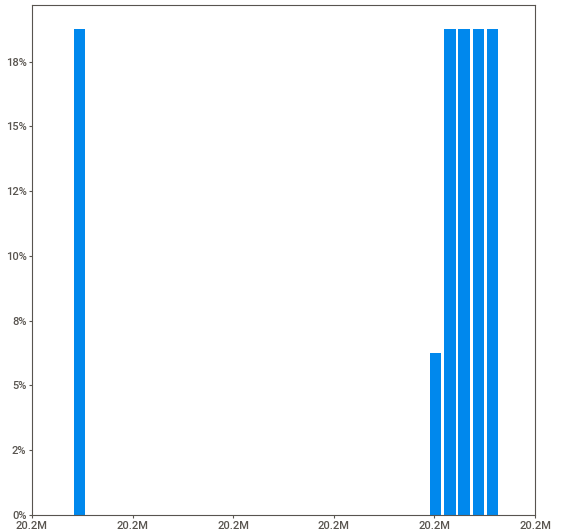
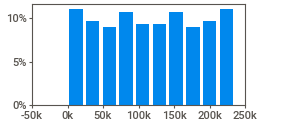
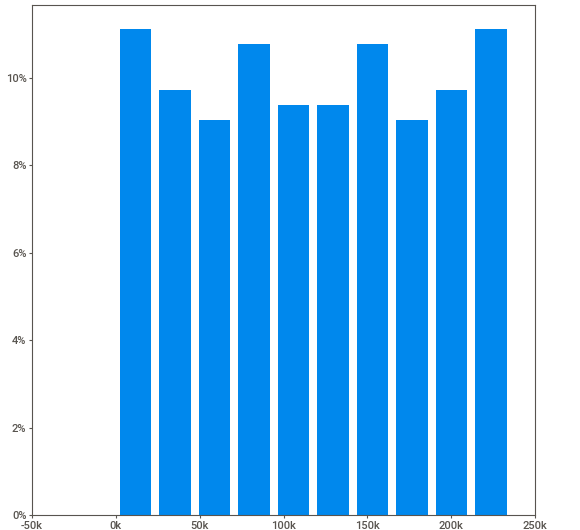
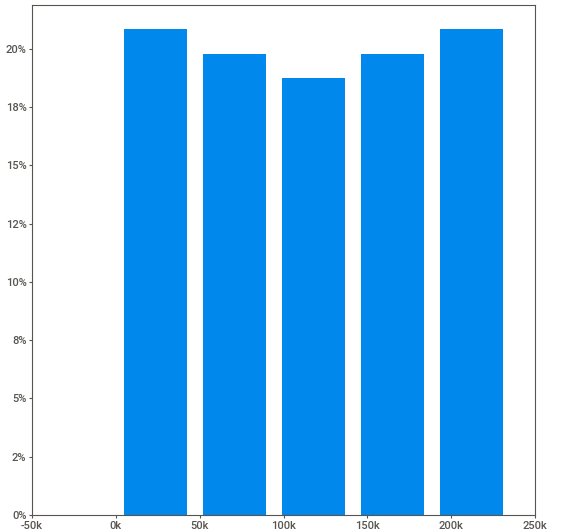
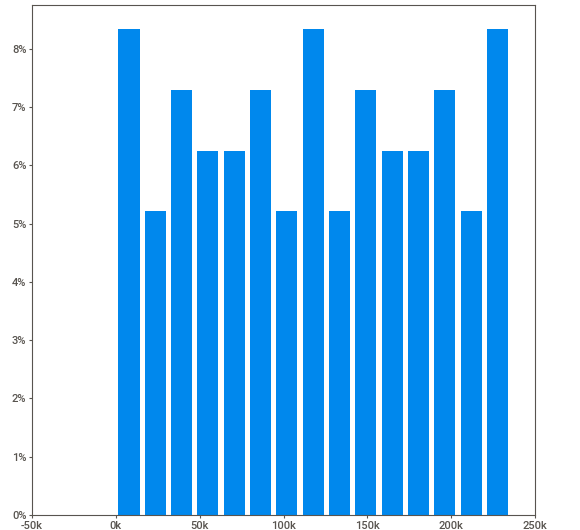
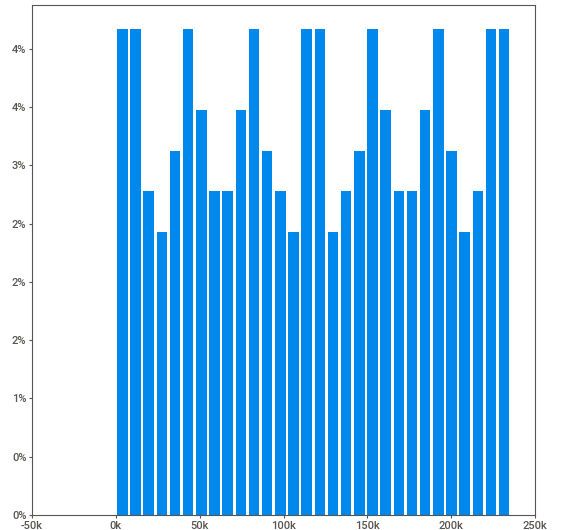
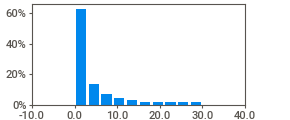
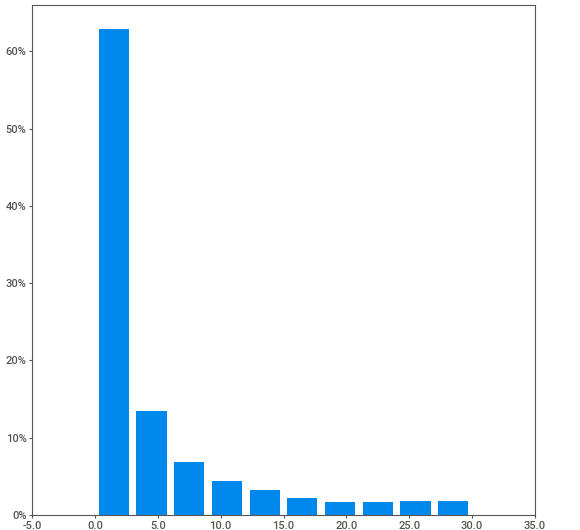
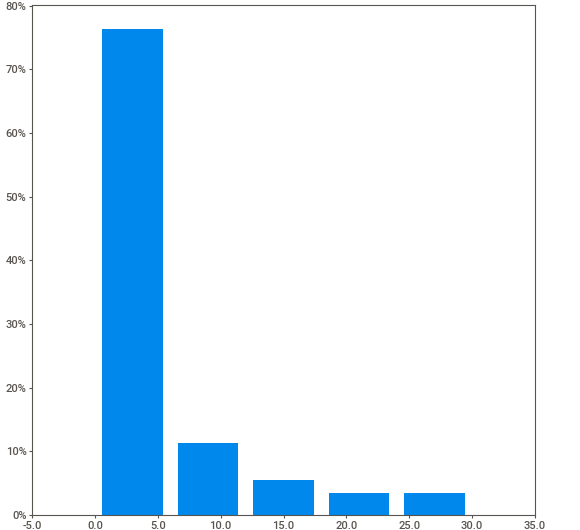
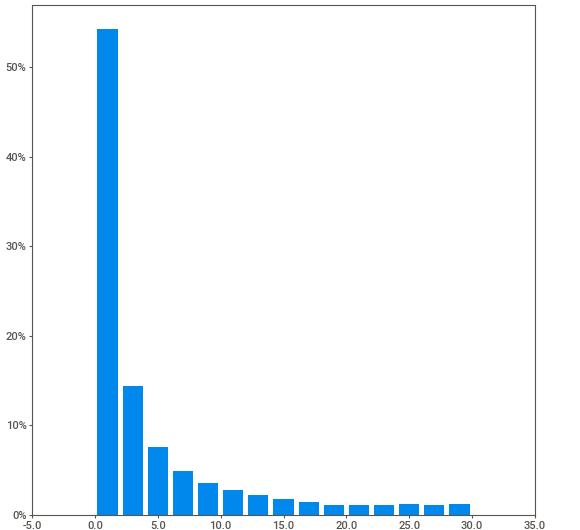
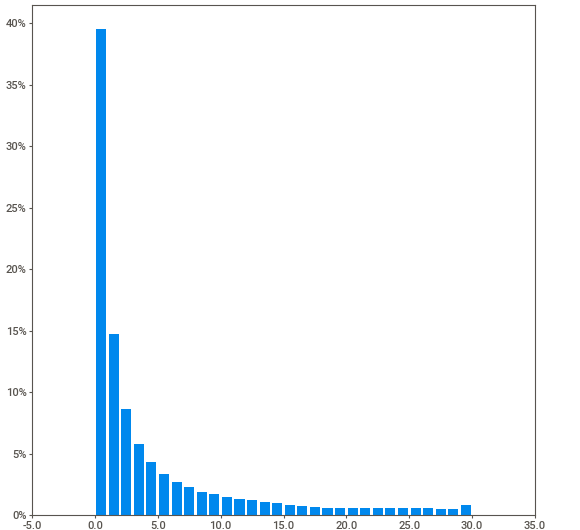
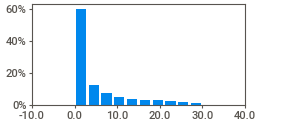
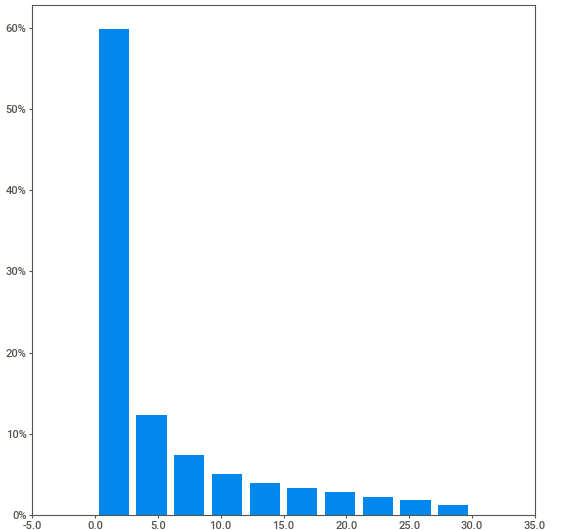
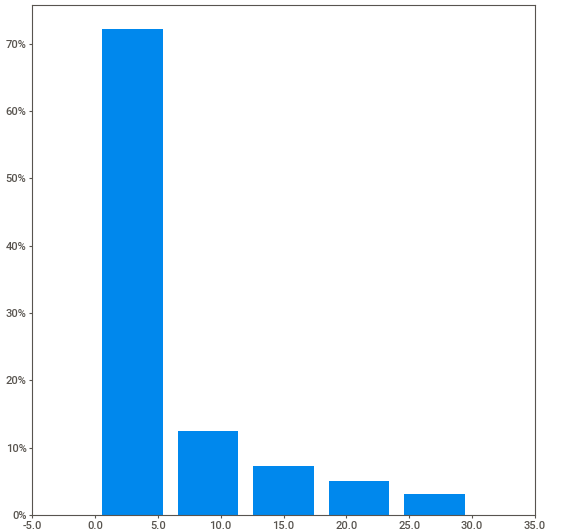
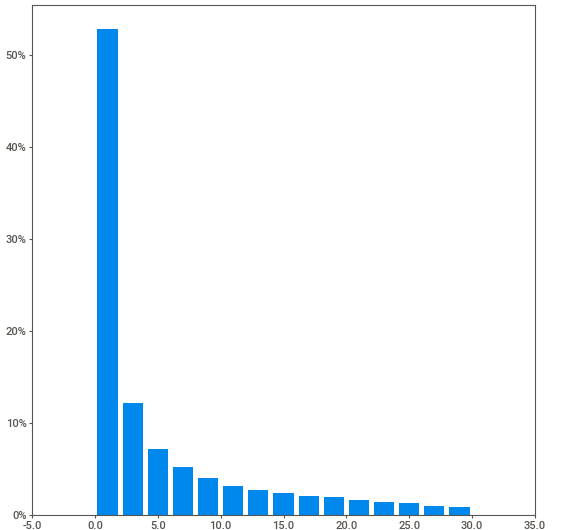
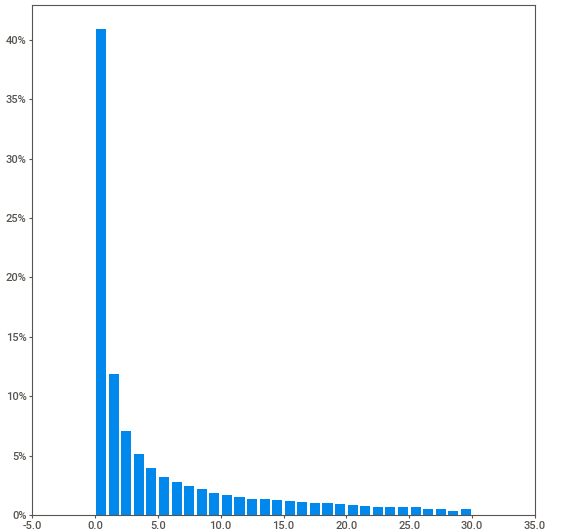
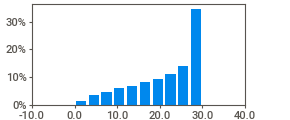
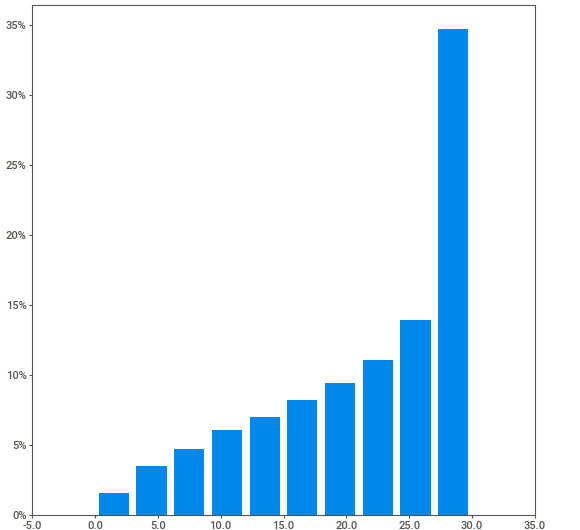
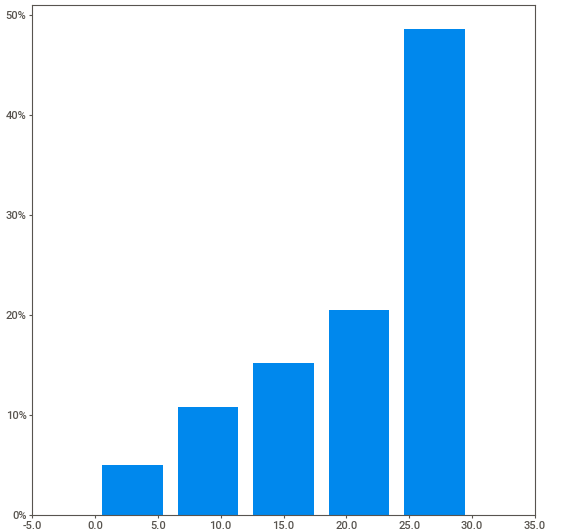
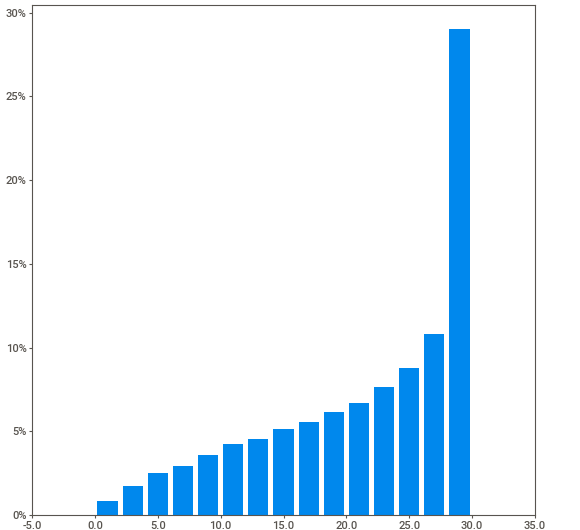
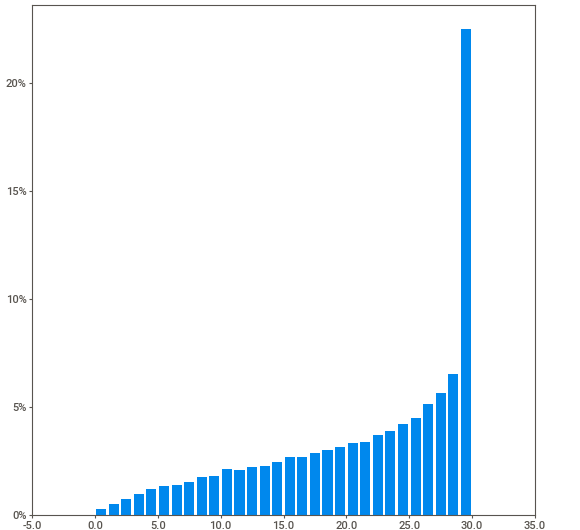
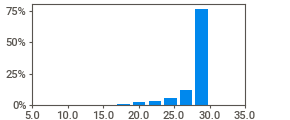
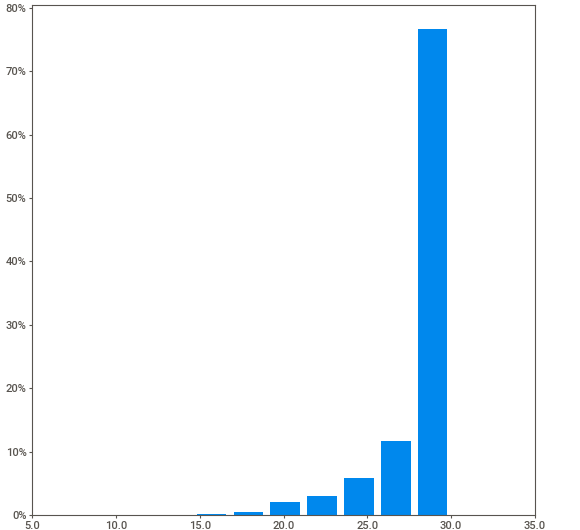
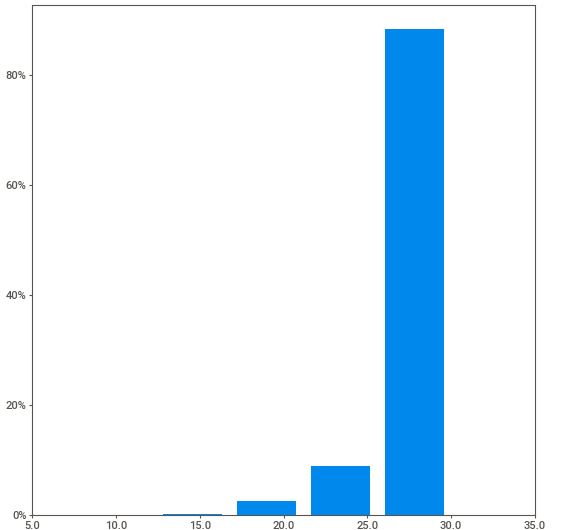
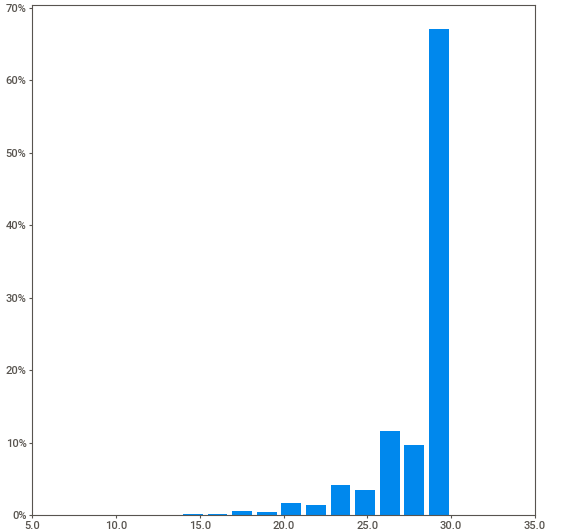
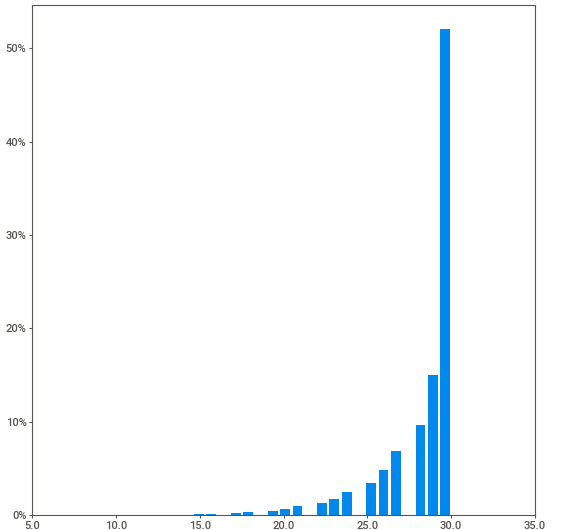
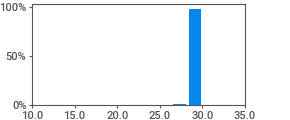
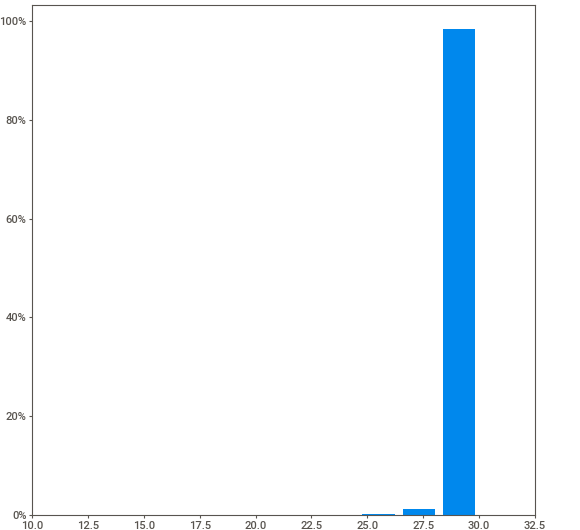
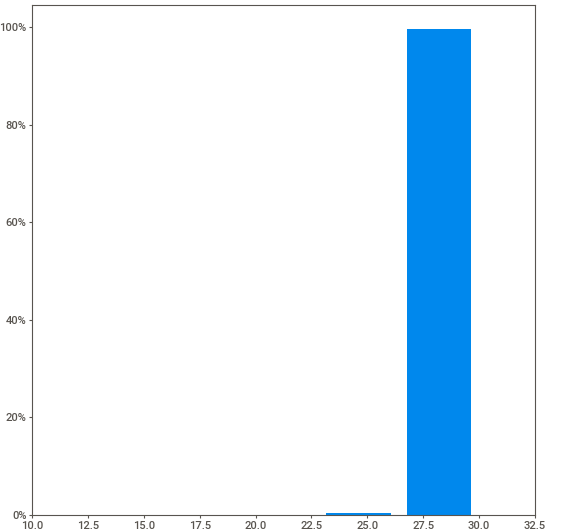
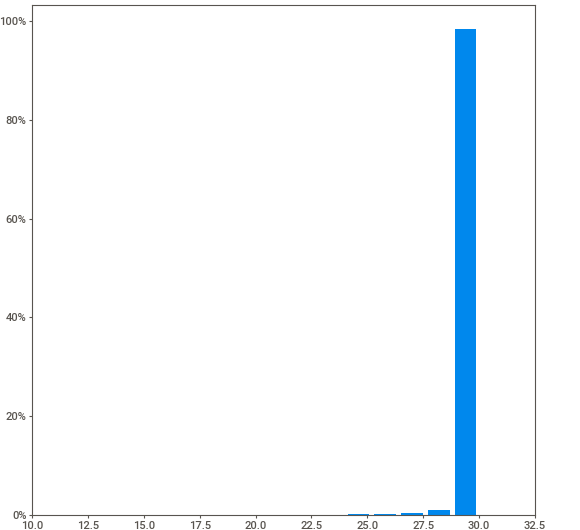
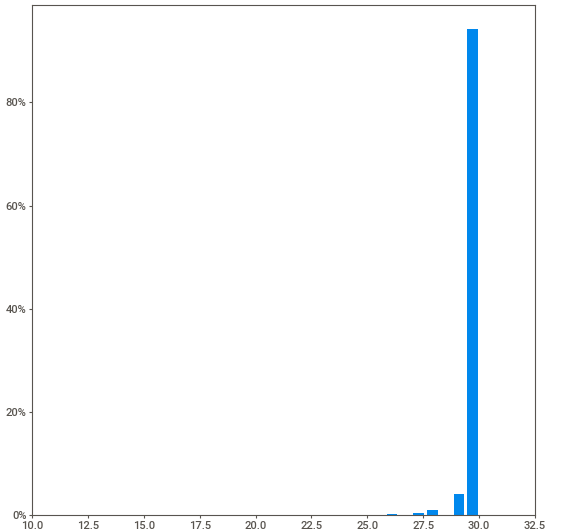
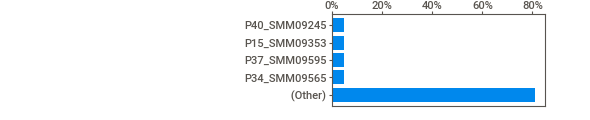
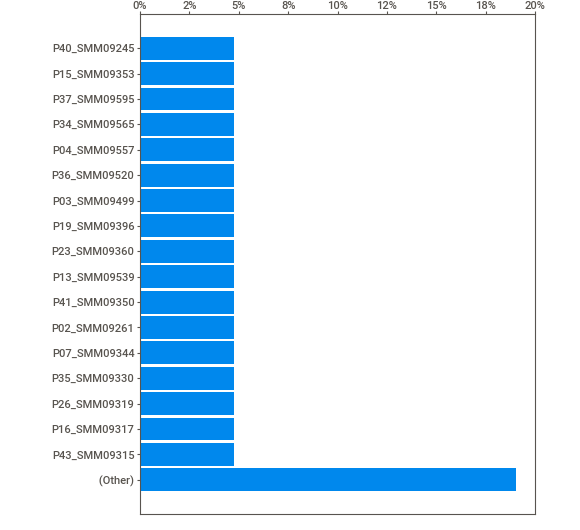
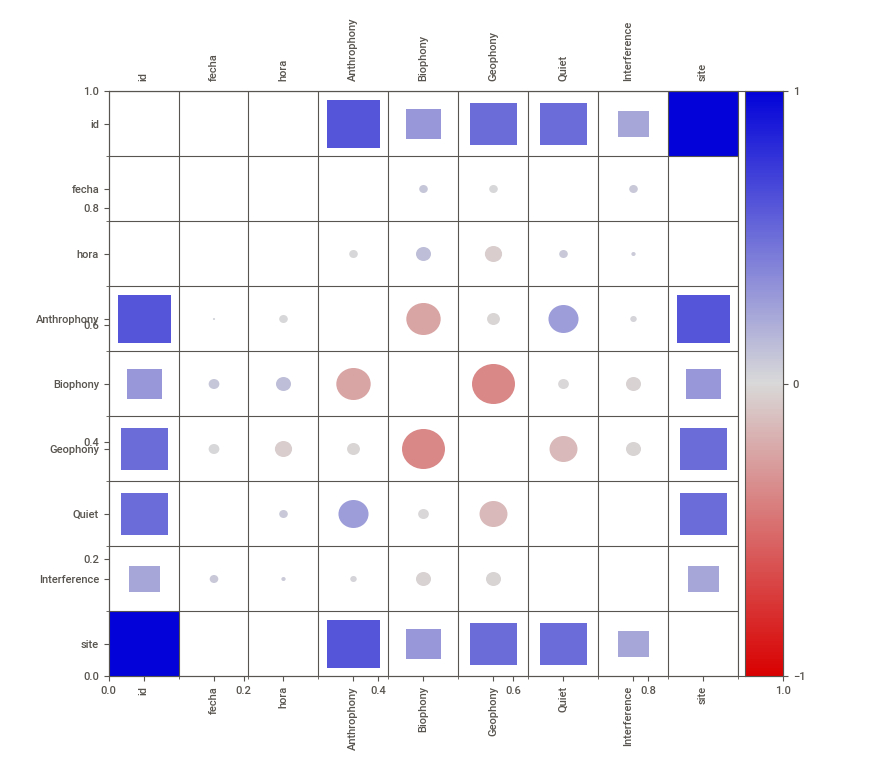
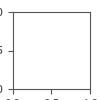

In [2]:
import sweetviz as sv

# Data profiler de sweetviz
report1 = sv.analyze([indices, "Índices"])  # Indicar el DataFrame a analizar
report2 = sv.analyze([riquezas, "Riquezas"])
report3 = sv.analyze([biofonias, "Biofonías"])

# Generar reporte
report1.show_notebook() # Muestra el reporte en el notebook
report2.show_notebook()
report3.show_notebook()

# Opcional: Guardar el reporte en un archivo HTML
#report1.show_html('indices_report.html') # Guarda el reporte en un archivo HTML
#report2.show_html('riquezas_report.html')
#report3.show_html('biofonias_report.html')

#### Informe de Análisis Exploratorio de Datos (EDA)

**Índices:**
Este Df contiene 19 columnas y 96.768 registros.
Las columnas de la 1 a la 6 contienen metadatos referentes cada registro tales como:
- datetime
- id (del grabador) 
- fecha
- hora
- site (donde se realizó la grabación)
- file (ruta archivo origen)

Las columnas de la 7 a la 19 contienen valores para 13 disitntos índices acústicos.
Ninguna de las variables presenta valores perdidos. 

**Riquezas:**
Este Df contiene 3 columnas y 96.768 registros.
Las columnas son:
- datetime
- site (donde se realizó la grabación)
- unique_species_count (numero de especies disitintas detectadas)

No se encontaron valores perdidos en ninguna de las varibles


**Biofonías:**
Este Df contiene 10 columnas y 96.768 registros.
Las columnas son las siguientes:
- id (del grabador)
- fecha 
- hora
- Anthrophony
- Biophony
- Geophony
- Quiet
- Interference
- datetime
- site (dode se realizó la grabación)



In [3]:
# Normalizar los valores de 'site' en todos los DataFrames para que tengan el mismo formato
indices['site'] = indices['site'].str.replace('-', '_')
riquezas['site'] = riquezas['site'].str.replace('-', '_')
biofonias['site'] = biofonias['site'].str.replace('-', '_')

# Asegúrate de que ambas columnas sean del mismo tipo
indices['datetime'] = pd.to_datetime(indices['datetime'])
riquezas['datetime'] = pd.to_datetime(riquezas['datetime'])
biofonias['datetime'] = pd.to_datetime(biofonias['datetime'])

# Merge de los DataFrames basado en 'datetime' y 'site'
merged_df = pd.merge(indices, riquezas, on=['datetime', 'site'])
merged_df = pd.merge(merged_df, biofonias, on=['datetime', 'site'])

# Visualización del DataFrame combinado
print(merged_df.head())

    datetime      id_x   fecha_x   hora_x          site  \
0 2023-09-28  SMM09353  20230928  0:00:00  P15_SMM09353   
1 2023-09-28  SMM09520  20230928  0:00:00  P36_SMM09520   
2 2023-09-28  SMM09557  20230928  0:00:00  P04_SMM09557   
3 2023-09-28  SMM09245  20230928  0:00:00  P40_SMM09245   
4 2023-09-28  SMM09565  20230928  0:00:00  P34_SMM09565   

                                                file         MEANt  \
0  /home/msg/Escritorio/Camilo_Behrens/20230928/P...  1.890000e-19   
1  /home/msg/Escritorio/Camilo_Behrens/20230928/P...  5.140000e-20   
2  /home/msg/Escritorio/Camilo_Behrens/20230928/P...  3.980000e-20   
3  /home/msg/Escritorio/Camilo_Behrens/20230928/P... -3.760000e-20   
4  /home/msg/Escritorio/Camilo_Behrens/20230928/P... -4.250000e-19   

           VARt        Ht     MEANf  ...          BI  unique_species_count  \
0  4.440000e-06  0.990822  0.000056  ...   28.838343                     0   
1  2.980000e-05  0.957052  0.000189  ...  156.819991                

**Unión de Dataframes**

<div style="text-align: justify;">
Se procede a unir los 3 dataframes en unos solo basado en datetime y site, dado que estos dos forman una clave primaria para cada registro. Primero se verificó que sitios tuvieran el mismo formato y que las columnas datetime tuviesen este formato.  
Finalmente se utilizó la funcion .merge de pandas indicando los df a unir y con el argumento 'on' para indicar las columnas clave en las que se basa la combinación.
</div>

In [4]:
# Eliminar columnas duplicadas o innecesarias

merged_df = merged_df.drop(columns=['file', 'id_y', 'fecha_y', 'hora_y', 'Anthrophony', 'Geophony', 'Quiet', 'Interference'])

print(merged_df.head())



    datetime      id_x   fecha_x   hora_x          site         MEANt  \
0 2023-09-28  SMM09353  20230928  0:00:00  P15_SMM09353  1.890000e-19   
1 2023-09-28  SMM09520  20230928  0:00:00  P36_SMM09520  5.140000e-20   
2 2023-09-28  SMM09557  20230928  0:00:00  P04_SMM09557  3.980000e-20   
3 2023-09-28  SMM09245  20230928  0:00:00  P40_SMM09245 -3.760000e-20   
4 2023-09-28  SMM09565  20230928  0:00:00  P34_SMM09565 -4.250000e-19   

           VARt        Ht     MEANf          VARf        Hf     SKEWf  \
0  4.440000e-06  0.990822  0.000056  5.520000e-09  0.713048  2.979317   
1  2.980000e-05  0.957052  0.000189  2.210000e-08  0.883924  0.787159   
2  8.940000e-07  0.984667  0.000037  3.600000e-10  0.918459  2.145733   
3  9.980000e-05  0.709976  0.000298  9.680000e-08  0.795403  2.198737   
4  1.081640e-04  0.950643  0.000333  1.020000e-07  0.812370  2.247418   

       KURTf         ACI      NDSI       ADI       AEI          BI  \
0  11.379908  297.205218 -0.786162  2.078736  0.0205

In [5]:
# Renombrar columnas
merged_df = merged_df.rename(columns={
    'id_x': 'id',
    'fecha_x': 'fecha',
    'hora_x': 'hora',
    'site': 'sitio',
    'unique_species_count': 'especies',
    'Biophony': 'biofonia'
})

# Visualización del DataFrame con los nuevos nombres de columnas
print(merged_df.head())

    datetime        id     fecha     hora         sitio         MEANt  \
0 2023-09-28  SMM09353  20230928  0:00:00  P15_SMM09353  1.890000e-19   
1 2023-09-28  SMM09520  20230928  0:00:00  P36_SMM09520  5.140000e-20   
2 2023-09-28  SMM09557  20230928  0:00:00  P04_SMM09557  3.980000e-20   
3 2023-09-28  SMM09245  20230928  0:00:00  P40_SMM09245 -3.760000e-20   
4 2023-09-28  SMM09565  20230928  0:00:00  P34_SMM09565 -4.250000e-19   

           VARt        Ht     MEANf          VARf        Hf     SKEWf  \
0  4.440000e-06  0.990822  0.000056  5.520000e-09  0.713048  2.979317   
1  2.980000e-05  0.957052  0.000189  2.210000e-08  0.883924  0.787159   
2  8.940000e-07  0.984667  0.000037  3.600000e-10  0.918459  2.145733   
3  9.980000e-05  0.709976  0.000298  9.680000e-08  0.795403  2.198737   
4  1.081640e-04  0.950643  0.000333  1.020000e-07  0.812370  2.247418   

       KURTf         ACI      NDSI       ADI       AEI          BI  especies  \
0  11.379908  297.205218 -0.786162  2.0787

**Limpieza**

<div style="text-align: justify;">
En las dos celdas anteriores se eliminaron columnas duplicadas y aquellas que no se utilizarán, y se modificó el nombre de algunas columnas para mayor claridad y homegeneidad en idioma y forma.
</div>

In [6]:
merged_df.dtypes

datetime    datetime64[ns]
id                  object
fecha                int64
hora                object
sitio               object
MEANt              float64
VARt               float64
Ht                 float64
MEANf              float64
VARf               float64
Hf                 float64
SKEWf              float64
KURTf              float64
ACI                float64
NDSI               float64
ADI                float64
AEI                float64
BI                 float64
especies             int64
biofonia             int64
dtype: object

In [7]:
merged_df.to_csv('df_limpio.csv', index=False)

**Verificación formatos**

<div style="text-align: justify;">
Se verificaron los formatos de cada columna y se rectificaron en caso de ser necesario.
Datetime ya había sido formateado como datetime para realizar el merge.
</div>

## Visualizaciones

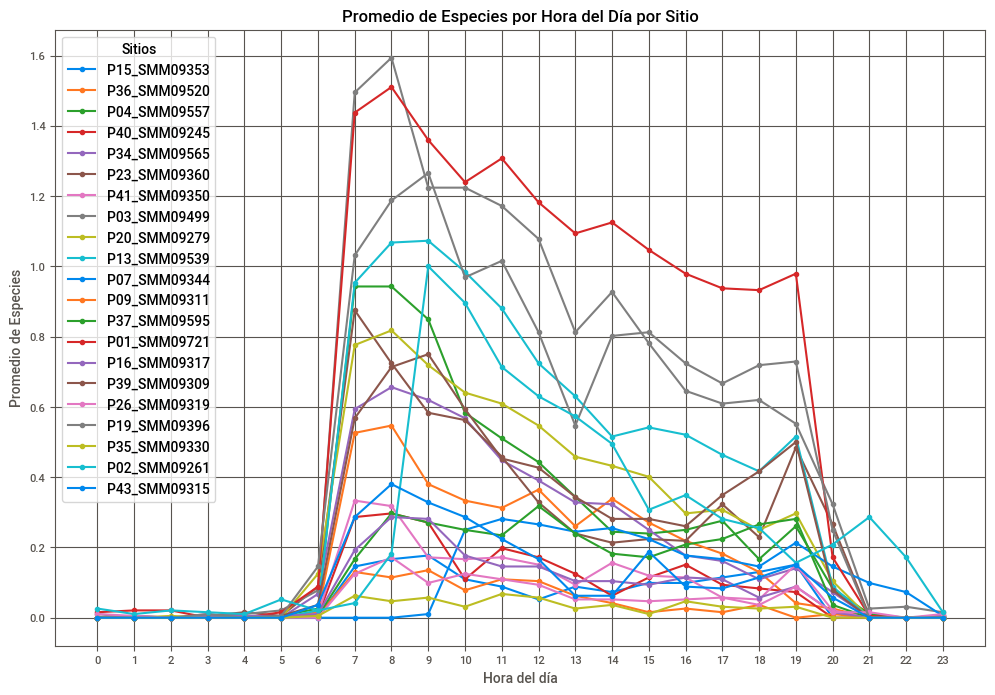

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Verificar si 'datetime' es datetime si no está ya convertido
merged_df['datetime'] = pd.to_datetime(merged_df['datetime'])

# Crear una nueva columna 'hora' que solo contenga la hora
merged_df['hora'] = merged_df['datetime'].dt.hour

# Graficar los valores para cada sitio
sitios = merged_df['sitio'].unique()

plt.figure(figsize=(12, 8))

for sitio in sitios:
    # Filtrar por sitio
    sitio_df = merged_df[merged_df['sitio'] == sitio]
    
    # Calcular el promedio de 'especies' para cada hora
    prom_diario = sitio_df.groupby('hora')['especies'].mean().reset_index()
    
    # Graficar los valores
    plt.plot(prom_diario['hora'], prom_diario['especies'], marker='o', linestyle='-', label=f'{sitio}')

# Configuración del gráfico
plt.xlabel('Hora del día')
plt.ylabel('Promedio de Especies')
plt.title('Promedio de Especies por Hora del Día por Sitio')
plt.grid(True)
plt.xticks(range(0, 24))  # Asegurarse de que todas las horas estén en el eje x
plt.legend(title='Sitios')
plt.show()


**Figura 1**

<div style="text-align: justify;">
En esta figura se graficaron el promedio de especies por hora durante los 15 días de grabación para cada sitio de muestreo.
Se evidencia que independiente de la magnitud del cambio, en todos los sitio existe un aumento del número promedio de especies a partir de las 6 horas. Tambien se puede apreciar que el número de especies tiende a disminuir a lo largo del día. Y por último, entorno a las 20 horas el número de especies tiende a cero en practicamente todos los sitios.
</div>

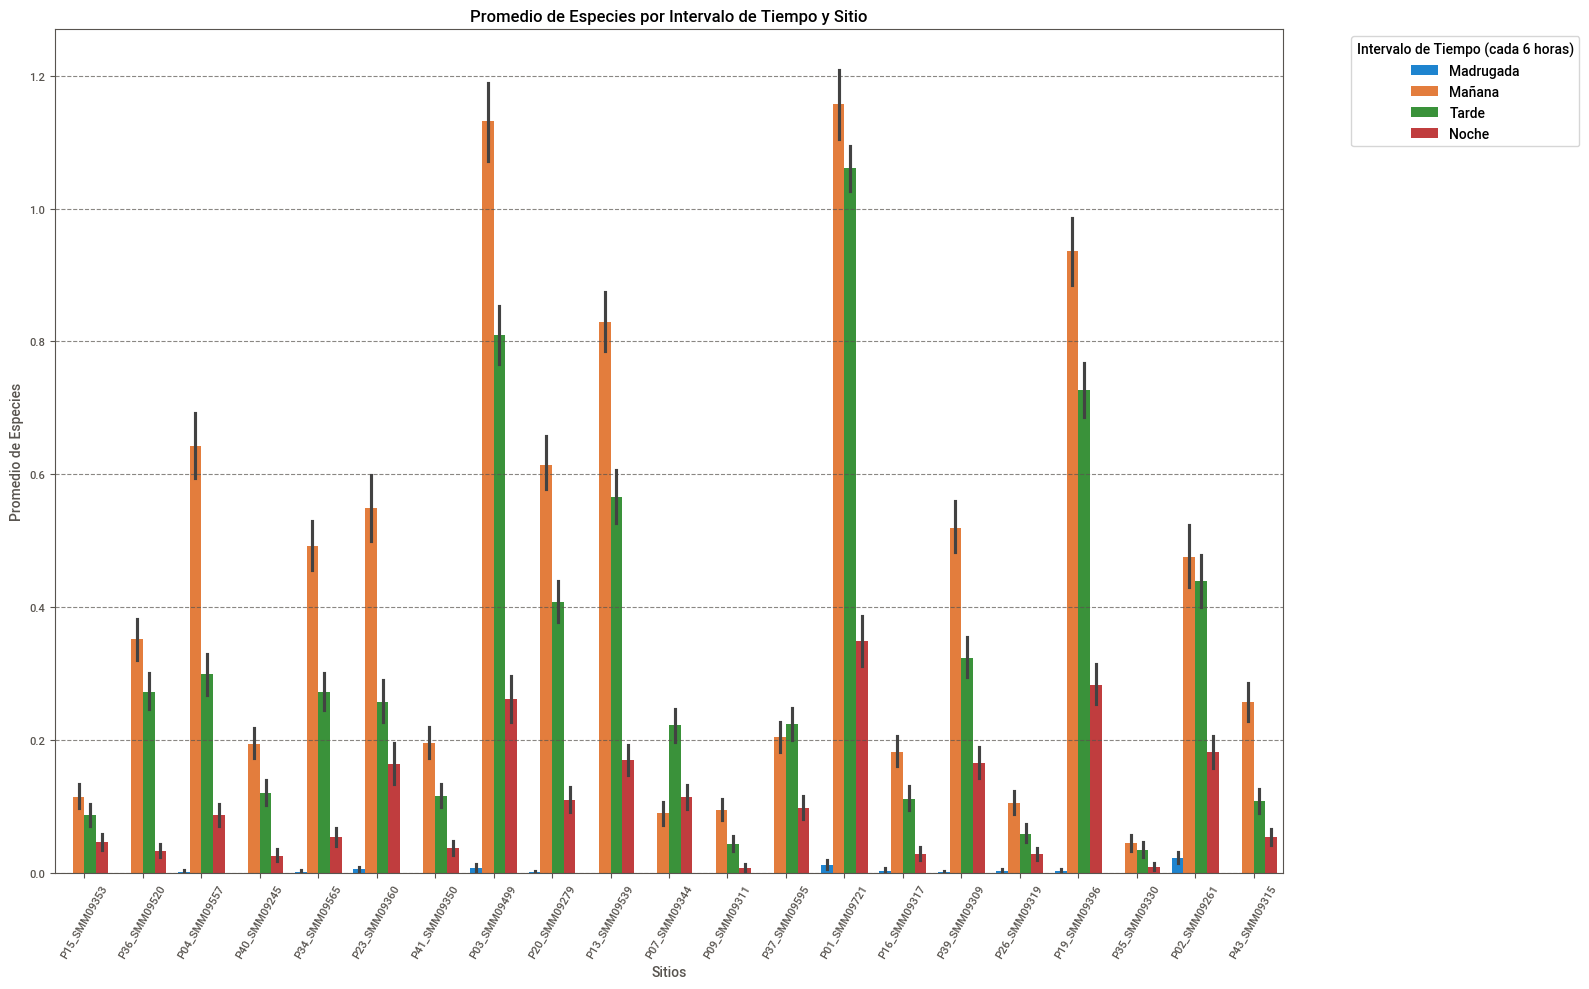

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convertir 'datetime' a datetime si no está ya convertido
merged_df['datetime'] = pd.to_datetime(merged_df['datetime'])

# Crear una nueva columna '6h_intervalo' que agrupe por intervalos de 6 horas
merged_df['6h_interval'] = (merged_df['datetime'].dt.hour // 6) * 6  # Agrupar horas en 0-5, 6-11, etc.

# Mapear los intervalos a etiquetas legibles
interval_labels = {0: 'Madrugada', 6: 'Mañana', 12: 'Tarde', 18: 'Noche'}
merged_df['6h_interval_label'] = merged_df['6h_interval'].map(interval_labels)

# Configurar el tamaño del gráfico
plt.figure(figsize=(16, 10))

# Crear el gráfico de barras agrupado por sitio e intervalo de tiempo
sns.barplot(data=merged_df, x='sitio', y='especies', hue='6h_interval_label')

# Configuración del gráfico
plt.xlabel('Sitios')
plt.ylabel('Promedio de Especies')
plt.title('Promedio de Especies por Intervalo de Tiempo y Sitio')
plt.xticks(rotation=60)
plt.legend(title='Intervalo de Tiempo (cada 6 horas)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Figura 2**

<div style="text-align: justify;">
En esta figura se grafica la distribución del número de especies agrupados en rangos de cada 6 horas para cada sitio.
Se puede apreciar que en 15 de 21 sitios la mayor cantidad de especies se encuentran durante la mañana (naraja) y la tarde (verde). Mientras que durante la madrugada (azul) practicamente no se encuentran especies. 
</div>

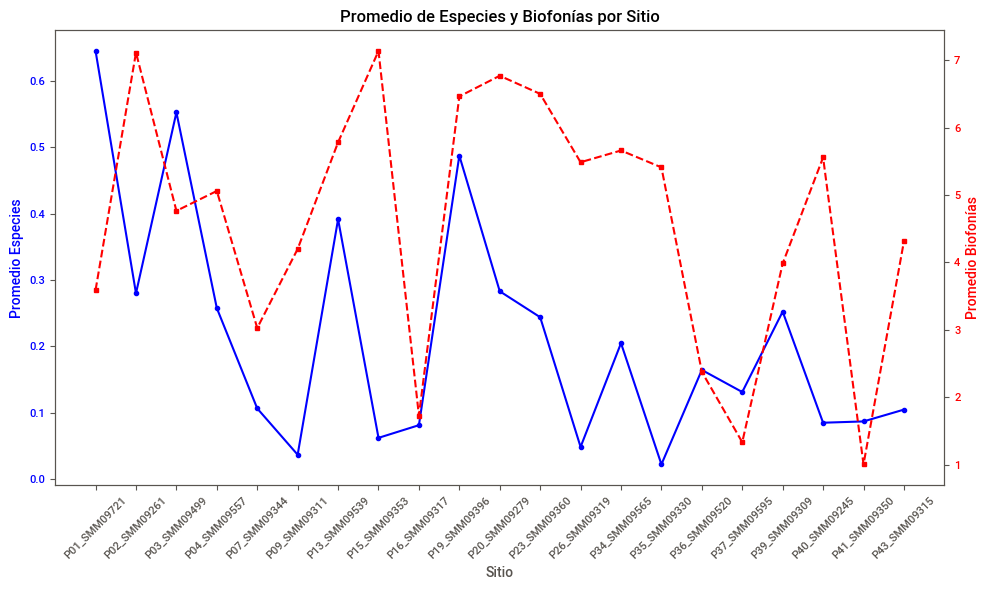

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

df = merged_df

# Calcular promedios por sitio
promedios = df.groupby('sitio').agg({'especies': 'mean', 'biofonia': 'mean'}).reset_index()

# Crear el gráfico
fig, ax1 = plt.subplots(figsize=(10, 6))

# Gráfico de líneas para especies
ax1.plot(promedios['sitio'], promedios['especies'], color='b', marker='o', label='Promedio Especies')
ax1.set_xlabel('Sitio')
ax1.set_ylabel('Promedio Especies', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Crear un segundo eje Y para biofonias
ax2 = ax1.twinx()
ax2.plot(promedios['sitio'], promedios['biofonia'], color='r', marker='s', linestyle='--', label='Promedio Biofonías')
ax2.set_ylabel('Promedio Biofonías', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Modificar las etiquetas del eje X para que estén en perpendicular
ax1.set_xticks(range(len(promedios['sitio'])))
ax1.set_xticklabels(promedios['sitio'], rotation=45)

# Agregar título y ajustar layout
plt.title('Promedio de Especies y Biofonías por Sitio')
fig.tight_layout()  # Ajustar el layout para evitar superposiciones

# Mostrar el gráfico
plt.show()



**Figura 3**

<div style="text-align: justify;">
En esta figura se grafica el promedio total (durante los 15 días) tanto para especies (linea continua azul) como para Biofonías (linea punteada roja). 
Se puede apreciar que existen sitio en los cuales hay una concordancia entre ambas variables (e.g. P13, P16, P19), mientras que hay otros sitios en los cuales se aprecia un desacople entre ambas variables (e.g. P01, P02, P40)
</div>

In [31]:
data = pd.read_csv('df_limpio.csv')
data2 = data[['MEANt', 'VARt', 'Ht', 'MEANf', 'VARf', 'Hf', 'SKEWf', 'KURTf', 'ACI', 'NDSI', 'ADI', 'AEI', 'BI', 'biofonia']]

# Feature Selection

Dado el elevado número de variables predictoras de la riqeuza de especies, se seleccionaran algunas mediante un Anáisis de Componentes Principales.
Tenien en cuenta que se cuenta con métricas de dimensión temporal (MEANt, VARt, Ht), espectral (MEANf, VARf, Hf, SKEWf, KURTf) y espectro-temporales (ACI, ADI, AEI) se espera que puedan existir variables con niveles de colinearidad a considerar.  

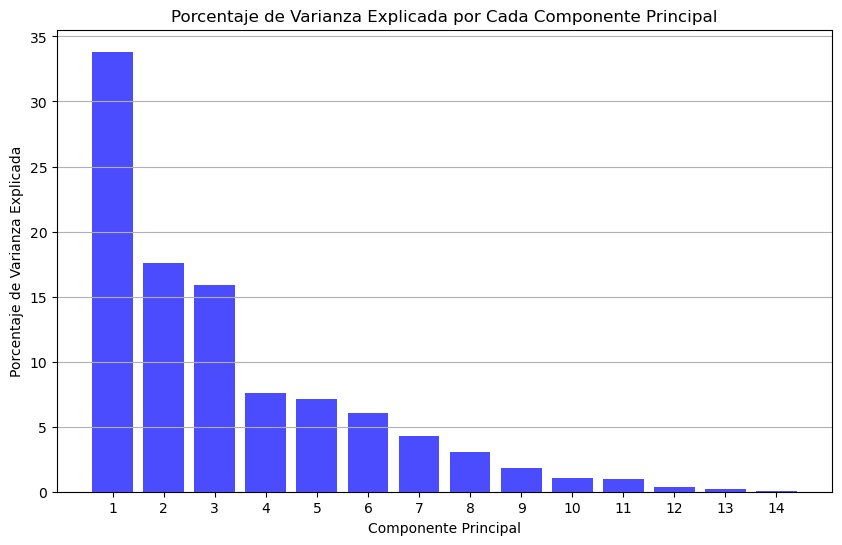

In [22]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Seleccionar las columnas predictoras y la variable respuesta
predictoras = ['MEANt', 'VARt', 'Ht', 'MEANf', 'VARf', 'Hf', 'SKEWf', 'KURTf', 'ACI', 'NDSI', 'ADI', 'AEI', 'BI', 'biofonia']
X = data[predictoras]
y = data['especies']

# Estandarizar las variables predictoras
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Realizar el PCA con 14 componentes
pca = PCA(n_components=14)
X_pca = pca.fit_transform(X_scaled)

# Crear un DataFrame con los resultados del PCA
pca_df = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(14)])
pca_df['especies'] = y

# Calcular el porcentaje de varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_ * 100

# Crear un gráfico de barras con el porcentaje de varianza explicada
plt.figure(figsize=(10, 6))
plt.bar(range(1, 15), varianza_explicada, alpha=0.7, color='blue')
plt.title('Porcentaje de Varianza Explicada por Cada Componente Principal')
plt.xlabel('Componente Principal')
plt.ylabel('Porcentaje de Varianza Explicada')
plt.xticks(range(1, 15))
plt.grid(axis='y')
plt.show()

**Figura 4**

El Análisis de Componentes Pricipales muestra que más del 50% de la varianza es explicada por las primeras 3 componentes. Las restantes componentes no alcanzan a explicar ni un 10% de la varianza. 

Las tres celdas siguientes tienen como objetivo realizar un análisis de componentes principales (PCA) para reducir la dimensionalidad de los datos y visualizar la relación entre las variables predictoras y la variable respuesta. Precisamente, se utilizaran solo las primeras tres componentes.

In [52]:
# usé .components_ para ver los vectores de los componentes
# guardar esta información en un dataframe
lista_componentes = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14']
componentes = pd.DataFrame(data=pca.components_, columns = data2.columns, index=lista_componentes)
componentes

,MEANt,VARt,Ht,MEANf,VARf,Hf,SKEWf,KURTf,ACI,NDSI,ADI,AEI,BI,biofonia
PC1,0.007547,0.278851,-0.191394,0.290746,0.289189,-0.376276,0.343096,0.349440,0.264955,-0.141095,-0.345562,0.350017,0.054191,-0.031820
PC2,0.049018,0.475395,0.163605,0.452452,0.454143,0.212275,-0.231722,-0.181415,0.176286,0.187140,0.246310,-0.242316,0.123843,-0.037195
PC3,0.014442,0.128607,0.464032,0.018944,0.129017,-0.086632,0.294607,0.247980,-0.312572,-0.475165,0.210532,-0.282352,-0.375302,0.082152
PC4,0.070998,0.056939,-0.261194,0.019464,0.044416,0.141850,-0.019242,-0.116401,0.161157,0.031058,-0.025802,0.054551,-0.462839,0.801439
PC5,0.992733,-0.014328,-0.016332,0.005653,-0.039444,-0.011756,-0.006219,-0.009823,-0.075530,-0.012096,-0.029039,0.027015,0.018269,-0.066262
PC6,-0.011172,0.033034,-0.312165,-0.016938,0.021434,0.227548,0.033949,-0.103481,0.225826,-0.071707,0.017558,-0.018450,-0.663902,-0.582579
PC7,-0.051666,0.116966,0.005461,0.084379,0.086583,-0.042677,-0.395961,-0.483223,-0.303355,-0.542929,-0.356611,0.249618,0.005516,-0.024184
PC8,0.046669,-0.189826,0.053264,-0.014129,-0.153822,-0.197794,-0.082632,-0.144527,0.696134,-0.504899,0.268290,-0.157322,0.172773,0.046321
PC9,-0.025219,0.095110,-0.632721,0.077413,0.009908,-0.430804,0.013750,-0.093011,-0.348838,-0.062724,0.473039,-0.184181,0.078280,-0.004539
PC10,-0.013069,-0.016266,-0.343447,0.207242,-0.121632,0.667494,0.097819,0.326445,-0.096753,-0.379378,-0.032428,-0.106014,0.307973,0.041896


In [37]:
# con .transform se calcula la función para cada dato y generando el resultado
# luego se guarda en un dataframe
proyecciones = pd.DataFrame(pca.transform(data2), index=data2.index,columns=lista_componentes)
proyecciones

/Users/camilobehrens/miniconda3/envs/indices/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but PCA was fitted without feature names
  warnings.warn(


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14
0,84.249512,53.883194,-98.817989,32.932761,-22.126354,46.839931,-97.012739,210.849518,-102.341633,-15.503269,-26.969167,4.806902,0.313112,20.957401
1,88.235478,72.467427,-151.055358,-24.771774,-19.939002,-36.737877,-93.173507,235.713728,-92.811109,20.451230,-44.755695,-0.185004,-25.763573,24.215381
2,82.499459,55.073312,-100.795692,32.873509,-22.066858,46.376741,-95.340974,211.081898,-102.007305,-16.601488,-26.681372,4.772305,-1.565433,20.955563
3,95.840110,67.258881,-129.835138,18.944059,-24.253132,26.156672,-107.310131,246.172879,-112.366945,-6.773676,-35.992789,3.943563,-9.034440,24.719927
4,89.155178,65.030269,-129.099527,3.430228,-21.624944,4.086113,-98.800300,229.343688,-100.365397,3.083016,-37.126175,2.421278,-12.986777,23.274526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96763,93.769405,48.819636,-91.322091,32.128793,-22.590757,47.334179,-110.612630,207.340911,-105.603269,-8.607307,-29.467483,5.488337,14.973631,21.097980
96764,87.075736,52.788281,-98.162260,32.514628,-22.301748,41.529335,-100.553236,210.607147,-102.552993,-11.773338,-28.356232,4.722455,3.020451,21.085335
96765,103.778574,74.709653,-150.426740,2.333433,-24.766216,2.353270,-112.111049,265.553080,-115.395711,5.125053,-43.476124,2.810231,-16.238026,26.924371
96766,84.572778,52.001387,-94.269158,37.632351,-22.343497,52.026969,-98.783051,207.909112,-103.190749,-17.278807,-25.890861,5.235866,3.695270,20.686702


In [38]:
# en esta celda se eliminan las componentes que no se utilizarán debido al bajo porcentaje de varianza explicada.

proyecciones.drop(columns=['PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14'], inplace=True)
proyecciones

,PC1,PC2,PC3
0,84.249512,53.883194,-98.817989
1,88.235478,72.467427,-151.055358
2,82.499459,55.073312,-100.795692
3,95.840110,67.258881,-129.835138
4,89.155178,65.030269,-129.099527
...,...,...,...
96763,93.769405,48.819636,-91.322091
96764,87.075736,52.788281,-98.162260
96765,103.778574,74.709653,-150.426740
96766,84.572778,52.001387,-94.269158


In [39]:
# Agreguemos la columna de las especies para poderla utilizar.
proyecciones['especies'] = data['especies']
proyecciones

,PC1,PC2,PC3,especies
0,84.249512,53.883194,-98.817989,0
1,88.235478,72.467427,-151.055358,0
2,82.499459,55.073312,-100.795692,0
3,95.840110,67.258881,-129.835138,0
4,89.155178,65.030269,-129.099527,0
...,...,...,...,...
96763,93.769405,48.819636,-91.322091,0
96764,87.075736,52.788281,-98.162260,0
96765,103.778574,74.709653,-150.426740,0
96766,84.572778,52.001387,-94.269158,0


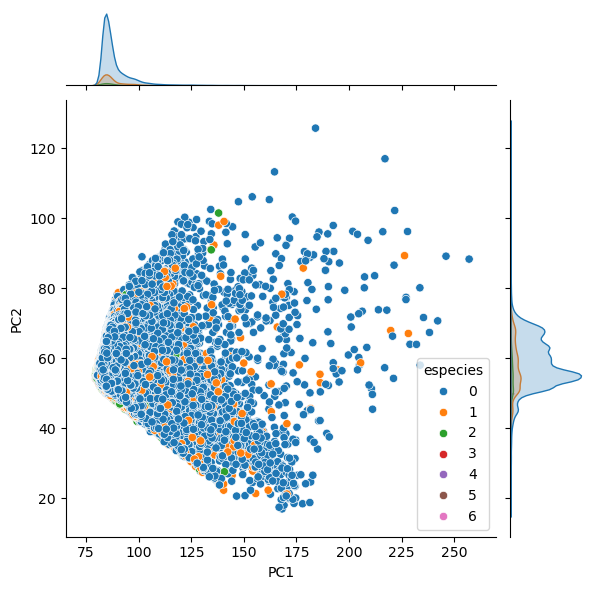

In [59]:
import seaborn as sns

# Aquí se puede ver la distribución y la relación entre las componentes 1 y 2
g = sns.jointplot(x='PC1', y='PC2', data=proyecciones, hue="especies", palette="tab10")
g.fig.set_figwidth(6)


**Figura 5**

En esta figura se pueden visualizar las distribuciones de las datos de especies en los componentes principales uno y dos. 

No se aprecia ningún tipo de agrupación ni tendencia, además la gran cantidad de valores de especies igual a cero tienden a enmascarar el resto de registros.

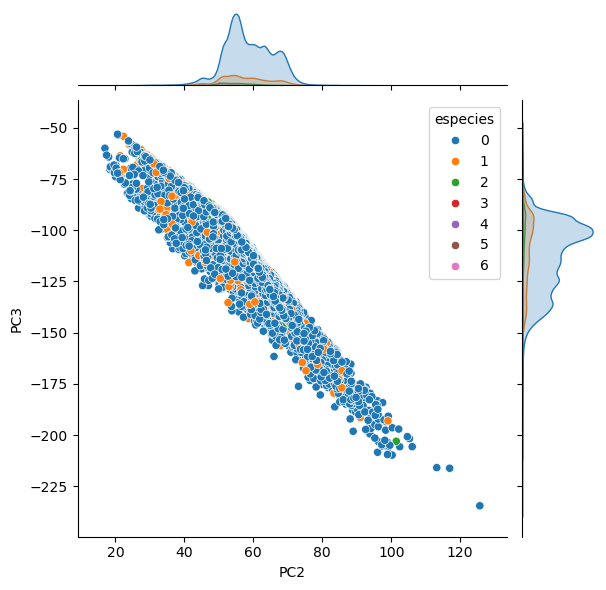

In [60]:
import seaborn as sns

# Aquí se puede ver la distribución y la relación entre las componentes 2 y 3
g = sns.jointplot(x='PC2', y='PC3', data=proyecciones, hue="especies", palette="tab10")
g.fig.set_figwidth(6)


**Figura 6**

En esta figura se pueden visualizar las distribuciones de las datos de especies en los componentes principales dos y tres.

No se aprecia ninguna agrupación o tendencia respecto a los valores de especies, la gran cantidad de ceros tiende a enmascarar el resto de registros. 

In [43]:
# mediante este código se puede ver el porcentaje de cada valor de especies en el conjunto de datos.
proyecciones.especies.value_counts(normalize=True)*100

especies
0    82.516948
1    14.002563
2     2.951389
3     0.467097
4     0.055804
5     0.004134
6     0.002067
Name: proportion, dtype: float64

Se puede apreciar que una gran proporción de los datos corresponden a valores de especies igual a cero.

*de aquí en adelante se realizará todo lo relacionado con el modelo de machine learning, desde la creación de los conjuntos de entrenamiento y prueba hasta la implementación del modelo y la obtención de las métricas para su validación*

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn import metrics

In [45]:
proyecciones_features=proyecciones[["PC1", "PC2", "PC3"]]
proyecciones_features

,PC1,PC2,PC3
0,84.249512,53.883194,-98.817989
1,88.235478,72.467427,-151.055358
2,82.499459,55.073312,-100.795692
3,95.840110,67.258881,-129.835138
4,89.155178,65.030269,-129.099527
...,...,...,...
96763,93.769405,48.819636,-91.322091
96764,87.075736,52.788281,-98.162260
96765,103.778574,74.709653,-150.426740
96766,84.572778,52.001387,-94.269158


In [46]:
proyecciones_target=proyecciones[["especies"]]
proyecciones_target

,especies
0,0
1,0
2,0
3,0
4,0
...,...
96763,0
96764,0
96765,0
96766,0


In [47]:
# Separamos en entrenamiento/test en razon 80/20 %
X_train, X_test, y_train, y_test = train_test_split(proyecciones_features,proyecciones_target,test_size=0.2, random_state=2,stratify=proyecciones_target)
# Creamos un KNN
modelo = KNeighborsClassifier(n_neighbors=7)
modelo.fit(X_train, y_train)
# Obtenemos las predicciones del modelo con X_test

/Users/camilobehrens/miniconda3/envs/indices/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=7)

**Selección del Modelo**

Si bien el número de especies es un tipo de dato númerico, estos se comportan más como una categoría. Debido a esto es que se ha elegido un modelo basado en el algoritmo de clasificación K-Nearest-Neighbor.

Dado que se tienen 7 posibles valores de número de especies (0-6) se elige un valor de k igual a siete.

In [ ]:
# se crean los objetos para asociar las predicciones tanto para el conjunto de entrenamiento como para el de test.
preds_train = modelo.predict(X_train)
preds_test = modelo.predict(X_test)

In [49]:
# se imprimen las métricas de evaluación para el conjunto de entrenamiento.
print(metrics.classification_report(y_train, preds_train))

              precision    recall  f1-score   support

           0       0.84      0.99      0.91     63880
           1       0.58      0.12      0.20     10840
           2       0.50      0.06      0.10      2285
           3       0.25      0.00      0.01       361
           4       0.00      0.00      0.00        43
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         2

    accuracy                           0.84     77414
   macro avg       0.31      0.17      0.17     77414
weighted avg       0.79      0.84      0.78     77414



/Users/camilobehrens/miniconda3/envs/indices/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/camilobehrens/miniconda3/envs/indices/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/camilobehrens/miniconda3/envs/indices/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [50]:
# se imprimen las métricas de evaluación para el conjunto de test.
print(metrics.classification_report(y_test, preds_test))

/Users/camilobehrens/miniconda3/envs/indices/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/camilobehrens/miniconda3/envs/indices/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.84      0.98      0.90     15970
           1       0.33      0.06      0.11      2710
           2       0.22      0.02      0.04       571
           3       0.00      0.00      0.00        91
           4       0.00      0.00      0.00        11
           5       0.00      0.00      0.00         1

    accuracy                           0.82     19354
   macro avg       0.23      0.18      0.18     19354
weighted avg       0.74      0.82      0.76     19354



/Users/camilobehrens/miniconda3/envs/indices/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Conclusiones

El modelo elegido para la clasificación del número de especies en función de las compenentes principales de las variables predictoras (indices acústicos) presenta resultados un tanto dicotómicos.

En cuanto a la precisión, en la clase 0 esta es alta lo que indica que el modelo clasifica de forma correcta el 84% de las veces.

Sin embargo, las clases restantes presentan bajos valores de precisión, lo que estaría indicando que el modelo tiende a confundir estas instancias.

Lo mismo ocurre con el recall, para la clase 0 casi todas las instancias reales de la clase 0 son correctamente identificadas por el modelo. Mientras que para el resto de clases los valores tienden a cero.

En consecuencia, los F1-score al ser una medida conjunta de la precisión y el recall, presentan la misma dinámica. Altos valores para la clase cero y bajos valores tendiendo a cero para el resto.

Teniendo en cuenta estos resultados se recomiendo re evaluar la aproximacón del análisis de estos datos, particularmente basado en el buen desempeño en la clasificación de la clases 0. Tal ves considerar una clave dicotómica de tipo presencia/ausencia ayude a mejorar el desempeño en la clasificación de las clases distintas de cero. 
